## Importando as biliotecas

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
import pandas as pd
from google.colab import files

# Faz o upload da base de dados
uploaded = files.upload()

# Lê todas as abas do arquivo Excel
df = pd.read_excel("LitDigestFull.xlsx", sheet_name=None)

print("Arquivo carregado com sucesso!")
print(df.keys())

Saving LitDigestFull.xlsx to LitDigestFull.xlsx
Arquivo carregado com sucesso!
dict_keys(['1924', '1928', '1932', '1936'])


Importando as bibliotecas:
  - NumPy : Biblioteca para resolver contas rápidas e mexer com listas, vetores e matrizes.
  - Pandas : O Pandas para criar e organizar tabelas de dados (DataFrames).

  - Matplotliv.pyplot : Biblioteca que desenha gráficos e os mostra na tela.

  - train_test_split, cross_val_score : Biblioteca que corta os dados em dois pedaços, uma parte para o modelo treinar e outra parte para testar e ver se ele aprendeu de verdade. E o cross_val_score ele faz a validação cruzada, que testa o modelo várias vezes em pedaços diferentes dos dados para ter certeza de que ele é bom mesmo
  - StandardScaler : Biblioteca que deixa todos os números na mesma medida para que o algoritmo não ache que um atributo é mais importante que o outro só porque tem números maiores.
  - Pipeline : Ele junta a etapa de arrumar os dados e padronizar com a etapa de treinar o modelo.
  - SVC : É a inteligência artificial que vai aprender a separar as espécies de flores e traçar a linha de decisão entre elas.
  - accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay : accuracy_score ele calcula a porcentagem geral de acertos do modelo, classification_report ele mostra um relatório completo com detalhes de precisão, revocação e nota geral, confusion_matrix ele monta a tabela mostrando onde o modelo acertou e onde ele se confundiu entre as espécies, ConfusionMatrixDisplay ele pega essa tabela de erros e desenha num gráfico colorido e fácil de entender. figure.figsize = (8, 5) : Ele define um tamanho padrão 8 de largura por 5 de altura para todos os gráficos que forem gerados no notebook, para que não fiquem gigantes.


## Definindo os dataframes

In [5]:
df = pd.read_excel("LitDigestFull.xlsx", sheet_name=None) # Definindo o DataFrame como o arquivo lido em .xlsx

Aqui o código lê o arquivo Excel "LitDigestFull.xlsx" e guarda todas as suas planilhas dentro de um dicionário, onde cada planilha vira um DataFrame separado.

In [6]:
# Tira os limites de exibição do pandas para exibir os DataFrames por inteiro
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

Esse código remove os limites que o pandas coloca por padrão na hora de mostrar as tabelas, fazendo com que todas as colunas e a largura total do DataFrame apareçam por inteiro na tela, sem cortar nada.

### DataFrame 1924

In [7]:
df_1924 = df['1924'] # Define o DataFrame de 1924 como a página de 1924 presente no arquivo

df_1924

,1924 VOTE,ELECTORAL VOTE,COOLIDGE,DAVIS,LA FOLLETTE,FARIS,FOSTER,NATIONS,WALLACE,JOHNS,TOTAL FOR STATE,Unnamed: 11,HOW THE SAME VOTERS VOTED IN 1920,REP.,DEM.,SOC.,FARM. LABOR,PROH.,DID NOT VOTE,TOTAL,Unnamed: 20,State - 1924,Electoral votes,Coolidge,%,Electoral votes.1,Davis,%.1,Electoral votes.2,LaFollette (Prog),%.2,Electoral votes.3,Faris (Proh.),%.3,Electoral votes.4,Foster (Comm.),%.4,Electoral votes.5,Johns (SL),%.5,Electoral votes.6,Margin,%.6,State Total,Unnamed: 44,https://en.wikipedia.org/wiki/1924_United_States_presidential_election
0,Alabama,12.0,5752,12186,1668,10,18,150,9,14,19807,NaN,Alabama,3943,12081,39,1,8,3735,19807,NaN,Alabama,12.0,45005.0,27.01,-,112966.0,67.81,12,8084.0,4.85,-,538,0.32,-,-,-,-,-,-,-,-67961.0,-40.79,166593.0,AL,NaN
1,Arizona,3.0,4272,2005,2230,5,10,47,4,20,8593,NaN,Arizona,3978,2966,41,8,13,1587,8593,NaN,Arizona,3.0,30516.0,41.26,3,26235.0,35.47,-,17210.0,23.27,-,-,-,-,-,-,-,-,-,-,4281.0,5.79,73961.0,AZ,NaN
2,Arkansas,9.0,5818,11210,2016,11,14,76,5,7,19157,NaN,Arkansas,4534,11266,64,4,3,3286,19157,NaN,Arkansas,9.0,40564.0,29.28,-,84795.0,61.21,9,13173.0,9.51,-,-,-,-,-,-,-,-,-,-,-44231.0,-31.93,138532.0,AR,NaN
3,California,13.0,76730,10280,65169,215,384,845,84,541,154248,NaN,California,92052,25214,2139,88,574,34181,154248,NaN,California,13.0,733250.0,57.20,13,105514.0,8.23,-,424649.0,33.13,-,18365,1.43,-,-,-,-,-,-,-,308601.0,24.07,1281900.0,CA,NaN
4,Colorado,6.0,19225,4711,6156,24,65,148,16,119,30464,NaN,Colorado,17293,6577,182,34,37,6341,30464,NaN,Colorado,6.0,195171.0,57.02,6,75238.0,21.98,-,69945.0,20.44,-,966,0.28,-,562,0.16,-,378,0.11,-,119933.0,35.04,342260.0,CO,NaN
5,Connecticut,7.0,25635,3856,4695,49,62,47,16,56,34416,NaN,Connecticut,23972,4347,188,28,46,5835,34416,NaN,Connecticut,7.0,246322.0,61.54,7,110184.0,27.53,-,42416.0,10.6,-,-,-,-,-,-,-,1373,0.34,-,136138.0,34.01,400295.0,CT,NaN
6,Delaware,3.0,2911,1362,357,1,10,12,2,5,4660,NaN,Delaware,2636,1182,13,1,3,825,4660,NaN,Delaware,3.0,52441.0,57.70,3,33445.0,36.80,-,4979.0,5.48,-,-,-,-,-,-,-,-,-,-,18996.0,20.90,90885.0,DE,NaN
7,Dist Columbia,0.0,4694,1471,1522,1,14,74,3,9,7788,NaN,Dist Columbia,2718,1060,24,2,3,3981,7788,NaN,Florida,6.0,30633.0,28.06,-,62083.0,56.88,6,8625.0,7.9,-,5498,5.04,-,-,-,-,-,-,-,-31450.0,-28.81,109154.0,FL,NaN
8,Florida,6.0,7567,9692,2316,26,16,321,11,22,19971,NaN,Florida,5151,10729,48,3,21,4019,19971,NaN,Georgia,14.0,30300.0,18.19,-,123200.0,73.96,14,12691.0,7.62,-,231,0.14,-,-,-,-,-,-,-,-92900.0,-55.77,166577.0,GA,NaN
9,Georgia,14.0,5541,17111,2642,12,11,31,10,14,25372,NaN,Georgia,3553,16978,24,1,8,4808,25372,NaN,Idaho,4.0,69879.0,47.12,4,24256.0,16.36,-,54160.0,36.52,-,-,-,-,-,-,-,-,-,-,15719.0,10.60,148295.0,ID,NaN


Esse código pega, dentro do dicionário criado antes, apenas a planilha referente ao ano de 1924 e guarda ela em um DataFrame próprio, para poder trabalhar só com esses dados.

### DataFrame 1928

In [8]:
df_1928 = df['1928'] # Define o DataFrame de 1928 como a página de 1928 presente no arquivo

df_1928

,Unnamed: 0,Unnamed: 1,Hoover (R),How the same voters voted in 1924,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Smith (D),How the same voters voted in 1924.1,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,VOTES FOR MINOR CANDIDATES,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,State - 1928,Electoral votes,Hoover,%,Electoral votes.1,Smith,%.1,Electoral votes.2,Thomas (Soc.),%.2,Electoral votes.3,Foster (Comm.),%.3,Electoral votes.4,Reynolds (Soc. Lab),%.4,Electoral votes.5,Margin,%.5,State total,State,Unnamed: 46
0,NaN,ELECTORAL VOTE,TOTAL 1928 VOTE,Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,NaN,TOTAL 1928 VOTE,Rep.,Dem.,soc.,F.Lab.,Proh.,No Vote,NaN,NaN,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total,NaN,Alabama,12.0,120725.0,48.49,-,127797.0,51.33,12,460,0.18,-,-,-,-,-,-,-,-7072.0,-2.84,248982.0,AL,NaN
1,ALABAMA,12,13997,4351,7221,41,1,10,2373,NaN,12298,757,9604,52,2,2,1881,NaN,NaN,ALABAMA,46,27,34,26402,NaN,Arizona,3.0,52533.0,57.57,3,38537.0,42.23,-,-,-,-,184,0.2,-,-,-,-,13996.0,15.34,91254.0,AZ,https://en.wikipedia.org/wiki/1928_United_Stat...
2,ARIZONA,3,3371,1840,936,37,0,2,556,NaN,2250,593,1197,58,4,0,398,NaN,NaN,ARIZONA,21,20,21,5683,NaN,Arkansas,9.0,77751.0,39.33,-,119196.0,60.29,9,429,0.22,-,317,0.16,-,-,-,-,-41445.0,-20.96,197693.0,AR,NaN
3,ARKANSAS,9,11652,4835,5107,44,3,4,1659,NaN,11267,963,8780,70,2,0,1452,NaN,NaN,ARKANSAS,79,28,26,23052,NaN,California,13.0,1162323.0,64.69,13,614365.0,34.19,-,19595,1.09,-,112,0.01,-,-,-,-,547958.0,30.50,1796656.0,CA,NaN
4,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,NaN,41566,22717,9766,1525,18,38,7502,NaN,NaN,CALIFORNIA,1014,447,434,132564,NaN,Colorado,6.0,253872.0,64.72,6,133131.0,33.94,-,3472,0.89,-,675,0.17,-,-,-,-,120741.0,30.78,392242.0,CO,NaN
5,COLORADO,6,16800,11236,2627,169,11,18,2739,NaN,6779,2452,2829,237,17,1,1243,NaN,NaN,COLORADO,136,74,73,23862,NaN,Connecticut,7.0,296614.0,53.63,7,252040.0,45.57,-,3019,0.55,-,730,0.13,-,622,0.11,-,44574.0,8.06,553031.0,CT,NaN
6,CONNECTICUT,7,24476,19724,1226,93,5,18,3410,NaN,10915,4665,4225,218,9,3,1795,NaN,NaN,CONNECTICUT,192,75,26,35684,NaN,Delaware,3.0,68860.0,65.03,3,36643.0,34.60,-,329,0.31,-,59,0.06,-,-,-,-,32217.0,30.42,105891.0,DE,NaN
7,DELAWARE,3,4113,2828,671,30,0,1,583,NaN,1422,356,803,26,1,0,236,NaN,NaN,DELAWARE,19,4,5,5563,NaN,Florida,6.0,144168.0,56.83,6,101764.0,40.12,-,4036,1.59,-,3704,1.46,-,-,-,-,42404.0,16.72,253672.0,FL,NaN
8,DIST. OF COLUMBIA,NaN,3765,1474,489,12,0,3,1787,NaN,2092,525,663,25,2,0,877,NaN,NaN,DIST. OF COLUMBIA,60,12,14,5943,NaN,Georgia,14.0,99369.0,43.36,-,129602.0,56.56,14,124,0.05,-,64,0.03,-,-,-,-,-30233.0,-13.19,229159.0,GA,NaN
9,FLORIDA,6,19022,7147,8753,56,1,18,3047,NaN,9951,1715,6567,58,3,4,1604,NaN,NaN,FLORIDA,65,29,33,29100,NaN,Idaho,4.0,97322.0,64.22,4,52926.0,34.93,-,1293,0.85,-,-,-,-,-,-,-,44396.0,29.30,151541.0,ID,NaN


Mesma ideia do bloco anterior, só que agora pegando a planilha referente ao ano de 1928 e guardando em outro DataFrame separado.

### DataFrame 1932

In [9]:
df_1932 = df['1932'] # Define o DataFrame de 1932 como a página de 19232 presente no arquivo

df_1932

,Unnamed: 0,Unnamed: 1,HOOVER,How the same Voters voted in 1928,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,ROOSEVELT,How the same Voters voted in 1928.1,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,VOTES FOR MINOR CANDIDATES,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,GRAND TOTAL VOTES,Unnamed: 25,Unnamed: 26,State - 1932,Electoral votes,Roosevelt,%,Electoral votes.1,Hoover,%.1,Electoral votes.2,Thomas (Soc.),%.2,Electoral votes.3,Other,%.3,Electoral votes.4,Margin,%.4,Total votes,Unnamed: 44
0,NaN,Electoral Votes,1932 Total Vote,Rep.,Dem.,Other,Did Not Vote,NaN,NaN,1932 Total Vote,Rep.,Dem.,Other,Did Not Vote,NaN,NaN,Thomas,Reynolds,Coxey,Upshaw,Foster,Miscellaneous,Totals,NaN,Total,NaN,NaN,Alabama,11.0,207910.0,84.74,11,34675.0,14.13,–,2030.0,0.83,–,739.0,0.30,–,173235,70.61,245354.0,https://en.wikipedia.org/wiki/1932_United_Stat...
1,ALABAMA,11,4272,3150,480,1,641,NaN,NaN,20161,3183,13629,4,3345,NaN,NaN,402,1,21,213,33,43,713,NaN,25146,NaN,NaN,Arizona,3.0,79264.0,67.03,3,36104.0,30.53,–,2618.0,2.21,–,265.0,0.22,–,43160,36.5,118251.0,NaN
2,ARIZONA,3,2574,2022,218,1,333,NaN,NaN,4910,1597,2581,2,730,NaN,NaN,254,1,18,53,21,15,362,NaN,7846,NaN,NaN,Arkansas,9.0,189602.0,85.96,9,28467.0,12.91,–,1269.0,0.58,–,1224.0,0.55,–,161135,73.06,220562.0,NaN
3,ARKANSAS,9,3712,2997,250,1,464,NaN,NaN,16225,2414,11564,5,2242,NaN,NaN,225,3,7,160,16,47,458,NaN,20395,NaN,NaN,California,22.0,1324157.0,58.39,22,847902.0,37.39,–,63299.0,2.79,–,32608.0,1.44,–,476255,21,2267966.0,NaN
4,CALIFORNIA,22,81834,67017,3847,99,10871,NaN,NaN,148832,77197,50252,340,21043,NaN,NaN,7874,115,213,1099,1444,565,11310,NaN,241976,NaN,NaN,Colorado,6.0,250877.0,54.81,6,189617.0,41.43,–,13591.0,2.97,–,3611.0,0.79,–,61260,13.38,457696.0,NaN
5,COLORADO,6,11950,9870,603,4,1473,NaN,NaN,14304,5730,6408,32,2134,NaN,NaN,1546,12,40,155,123,102,1978,NaN,28232,NaN,NaN,Connecticut,8.0,281632.0,47.40,–,288420.0,48.54,8,20480.0,3.45,–,3651.0,0.61,–,"−6,788",−1.14,594183.0,NaN
6,CONNECTICUT,8,26469,21590,1539,9,3331,NaN,NaN,16884,5521,8966,27,2370,NaN,NaN,4256,61,44,82,199,225,4867,NaN,48220,NaN,NaN,Delaware,3.0,54319.0,48.11,–,57073.0,50.55,3,1376.0,1.22,–,133.0,0.12,–,"−2,754",−2.44,112901.0,NaN
7,DELAWARE,3,2384,1809,229,0,346,NaN,NaN,2546,800,1308,7,431,NaN,NaN,205,1,3,30,17,23,279,NaN,5209,NaN,NaN,Florida,7.0,206307.0,74.68,7,69170.0,25.04,–,775.0,0.28,–,0.0,0.00,–,137137,49.64,276252.0,NaN
8,DISTRICT OF COLUMBIA,0,3937,2310,185,2,1440,NaN,NaN,5061,1299,1952,5,1805,NaN,NaN,514,4,5,41,83,50,697,NaN,9695,NaN,NaN,Georgia,12.0,234118.0,91.60,12,19863.0,7.77,–,461.0,0.18,–,1148.0,0.45,–,214255,83.83,255590.0,NaN
9,FLORIDA,7,9302,6944,880,3,1475,NaN,NaN,23606,6393,13411,5,3797,NaN,NaN,857,8,32,408,86,100,1491,NaN,34399,NaN,NaN,Idaho,4.0,109479.0,58.66,4,71417.0,38.27,–,526.0,0.28,–,5203.0,2.79,–,38062,20.39,186625.0,NaN


Mesma ideia do bloco anterior, só que agora pegando a planilha referente ao ano de 1932 e guardando em outro DataFrame separado.

### DataFrame 1936

In [10]:
df_1936 = df['1936'] # Define o DataFrame de 1936 como a página de 1936 presente no arquivo


df_1936

,Unnamed: 0,Unnamed: 1,Landon (R),How did they vote in 1932?,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Roosevelt (D),How did they vote in 1932?.1,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Lemke (Union),How did they vote in 1932?.2,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,MINOR CANDIDATES,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Grand Total Votes,Unnamed: 33,State - 1936,Electoral votes,Roosevelt,%,Electoral votes.1,Landon,%.1,Electoral votes.2,Lemke (Union).1,%.2,Electoral votes.3,Thomas (Soc.),%.3,Electoral votes.4,Other,%.4,Electoral votes.5,Margin,%.5,Total votes,State,Unnamed: 55
0,State,Electoral Vote,Landon,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,NaN,Roosevelt (D),Rep.,Dem.,Soc.,Others,Did Note Vote,Vote Not Indicated,NaN,Lemke,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,NaN,Thomas,Browder,Colvin,Aiken,Others,Totals,Total,NaN,Alabama,11.0,238136.0,86.38,11,35358.0,12.82,-,551,0.2,-,242,0.09,-,1397,0.51,-,202838.0,73.56,275244.0,AL,https://en.wikipedia.org/wiki/1936_United_Stat...
1,Alabama,11,3060,1218,1298,3,3,412,126,NaN,10082,371,8530,50,1,736,394,NaN,68,5,49,4,0,4,6,NaN,33,3,27,0,0,63,13273,NaN,Arizona,3.0,86722.0,69.85,3,33433.0,26.93,-,3307,2.66,-,317,0.26,-,384,0.31,-,53289.0,42.92,124163.0,AZ,NaN
2,Arizona,3,2337,1431,647,18,0,129,112,NaN,1975,248,1555,33,0,70,69,NaN,104,22,52,8,0,10,12,NaN,22,24,14,0,0,60,4476,NaN,Arkansas,9.0,146765.0,81.80,9,32039.0,17.86,-,4,0,-,446,0.25,-,169,0.09,-,114726.0,63.94,179423.0,AR,NaN
3,Arkansas,9,2724,1338,953,7,9,274,143,NaN,7608,228,6655,16,8,373,328,NaN,138,14,98,4,3,9,10,NaN,37,5,21,2,5,70,10540,NaN,California,22.0,1766836.0,66.95,22,836431.0,31.70,-,-,-,-,11331,0.43,-,24284,0.92,-,930405.0,35.26,2638882.0,CA,NaN
4,California,22,89516,65360,16200,315,53,3519,4069,NaN,77245,15165,53520,1816,63,3578,3103,NaN,4977,1620,2560,117,25,163,492,NaN,728,967,398,44,60,2197,173935,NaN,Colorado,6.0,295021.0,60.37,6,181267.0,37.09,-,9962,2.04,-,1593,0.33,-,841,0.17,-,113754.0,23.28,488684.0,CO,NaN
5,Colorado,6,15949,11872,2714,131,12,637,583,NaN,10025,1747,7256,284,13,439,286,NaN,579,136,333,29,2,26,53,NaN,122,49,41,10,11,233,26786,NaN,Connecticut,8.0,382129.0,55.32,8,278685.0,40.35,-,21805,3.16,-,5683,0.82,-,2421,0.35,-,103444.0,14.98,690723.0,CT,NaN
6,Connecticut,8,28809,22939,3376,111,7,1230,1146,NaN,13413,2584,9113,408,6,788,514,NaN,1489,245,1006,53,3,70,112,NaN,258,101,39,31,11,440,44151,NaN,Delaware,3.0,69702.0,54.62,3,57236.0,44.85,-,442,0.35,-,172,0.13,-,51,0.04,-,12466.0,9.77,127603.0,DE,NaN
7,Delaware,3,2918,2343,328,9,0,134,104,NaN,2048,503,1345,34,0,96,70,NaN,35,6,19,3,0,2,5,NaN,16,2,8,0,1,27,5028,NaN,Florida,7.0,249117.0,76.10,7,78248.0,23.90,-,-,-,-,-,-,-,-,-,-,170869.0,52.20,327365.0,FL,NaN
8,Florida,7,6087,3121,2051,13,5,594,303,NaN,8620,635,6924,41,0,614,406,NaN,195,37,116,6,2,12,22,NaN,58,22,31,6,2,119,15021,NaN,Georgia,12.0,255364.0,87.10,12,36942.0,12.60,-,141,0.05,-,68,0.02,-,660,0.23,-,218422.0,74.50,293175.0,GA,NaN
9,Georgia,12,3948,1239,1817,5,11,708,168,NaN,12915,379,10377,42,9,1569,539,NaN,35,3,23,1,0,6,2,NaN,45,12,27,0,17,101,16999,NaN,Idaho,4.0,125683.0,62.96,4,66256.0,33.19,-,7678,3.85,-,-,-,-,-,-,-,59427.0,29.77,199617.0,ID,NaN


Mesma ideia do bloco anterior, só que agora pegando a planilha referente ao ano de 1936 e guardando em outro DataFrame separado.

## Tratando as tabelas

### Tratamento DataFrame 1924

In [11]:
df_1924.shape # Mostra o formato do DataFrame (Linhas, Colunas)

(51, 46)

Esse código mostra a quantidade de linhas e colunas que o DataFrame de 1924 possui, para ter uma ideia geral do tamanho da tabela.

In [12]:
df_1924.isna().sum() # Mostra se há valores nulos no DataFrame

,0
1924 VOTE,1
ELECTORAL VOTE,1
COOLIDGE,0
DAVIS,0
LA FOLLETTE,0
FARIS,0
FOSTER,0
NATIONS,0
WALLACE,0
JOHNS,0


Aqui o código verifica, coluna por coluna, quantos valores nulos (vazios) existem no DataFrame de 1924.

In [13]:
df_1924.duplicated().sum() # Mostra se há valores duplicados

np.int64(0)

Esse código verifica se existem linhas inteiras duplicadas dentro do DataFrame de 1924.

In [14]:
df_1924.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 46 columns):
 #   Column                                                                  Non-Null Count  Dtype  
---  ------                                                                  --------------  -----  
 0   1924 VOTE                                                               50 non-null     object 
 1   ELECTORAL VOTE                                                          50 non-null     float64
 2   COOLIDGE                                                                51 non-null     int64  
 3   DAVIS                                                                   51 non-null     int64  
 4   LA FOLLETTE                                                             51 non-null     int64  
 5   FARIS                                                                   51 non-null     int64  
 6   FOSTER                                                                  51 non-null 

Esse código mostra um resumo geral da tabela, com o tipo de cada coluna, quantidade de valores não nulos e uso de memória.

In [15]:
df_1924.describe()

,ELECTORAL VOTE,COOLIDGE,DAVIS,LA FOLLETTE,FARIS,FOSTER,NATIONS,WALLACE,JOHNS,TOTAL FOR STATE,Unnamed: 11,REP.,DEM.,SOC.,FARM. LABOR,PROH.,DID NOT VOTE,TOTAL,Unnamed: 20,Electoral votes,Coolidge,%,Davis,%.1,LaFollette (Prog),Margin,%.6,State Total,https://en.wikipedia.org/wiki/1924_United_States_presidential_election
count,50.000000,5.100000e+01,51.000000,51.000000,51.000000,51.00000,51.000000,51.000000,51.000000,5.100000e+01,0.0,5.100000e+01,51.000000,51.000000,51.000000,51.000000,51.000000,5.100000e+01,0.0,49.000000,4.900000e+01,49.000000,4.900000e+01,49.000000,4.900000e+01,4.900000e+01,49.000000,4.900000e+01,0.0
mean,21.240000,5.286404e+04,19820.000000,19941.803922,64.156863,186.00000,491.137255,46.039216,157.490196,9.357067e+04,NaN,5.246031e+04,22230.039216,623.137255,138.431373,119.450980,17999.294118,9.357067e+04,NaN,21.673469,6.417873e+05,47.558163,3.422956e+05,35.645102,1.972125e+05,2.707384e+05,6.351224,1.187637e+06,NaN
std,74.060251,1.877550e+05,69929.620463,71156.449438,229.200294,670.17923,1754.137897,163.341233,562.028411,3.312352e+05,NaN,1.864518e+05,78448.409745,2251.467948,511.605913,432.019875,63725.005386,3.312352e+05,NaN,74.763624,2.238106e+06,16.003646,1.188745e+06,22.261931,6.891621e+05,1.066889e+06,34.311171,4.127890e+06,NaN
min,0.000000,1.230000e+03,348.000000,357.000000,0.000000,0.00000,1.000000,1.000000,4.000000,2.485000e+03,NaN,9.140000e+02,670.000000,4.000000,0.000000,1.000000,476.000000,2.485000e+03,NaN,3.000000,1.123000e+03,2.210000,5.909000e+03,6.800000,0.000000e+00,-3.545820e+05,-94.350000,2.692100e+04,NaN
25%,5.000000,5.908500e+03,2214.500000,1940.500000,6.500000,13.50000,47.000000,5.500000,20.000000,1.423500e+04,NaN,5.627000e+03,2938.500000,37.500000,4.000000,5.500000,2841.500000,1.423500e+04,NaN,5.000000,6.987900e+04,41.760000,4.854200e+04,19.380000,1.037700e+04,-2.765500e+04,-5.590000,1.569900e+05,NaN
50%,9.500000,1.500800e+04,8877.000000,4695.000000,15.000000,35.00000,148.000000,11.000000,44.000000,3.046400e+04,NaN,1.372400e+04,9710.000000,86.000000,17.000000,21.000000,5606.000000,3.046400e+04,NaN,10.000000,1.425790e+05,49.580000,1.055140e+05,29.130000,4.637500e+04,3.032600e+04,12.730000,3.422600e+05,NaN
75%,13.000000,3.408050e+04,15828.500000,11088.000000,44.000000,98.00000,319.500000,31.500000,103.500000,6.892950e+04,NaN,4.117350e+04,16030.000000,333.500000,49.000000,63.000000,13140.000000,6.892950e+04,NaN,13.000000,4.207590e+05,57.700000,2.572320e+05,45.980000,1.089010e+05,1.361380e+05,26.630000,8.408260e+05,NaN
max,531.000000,1.348033e+06,505410.000000,508516.000000,1636.000000,4743.00000,12524.000000,1174.000000,4016.000000,2.386052e+06,NaN,1.337738e+06,566866.000000,15890.000000,3530.000000,3046.000000,458982.000000,2.386052e+06,NaN,531.000000,1.572379e+07,78.220000,8.386242e+06,96.560000,4.831706e+06,7.337547e+06,62.550000,2.909711e+07,NaN


Aqui o código gera um resumo estatístico das colunas numéricas, mostrando média, desvio padrão, valores mínimo, máximo e os quartis.

In [16]:
# Deleta as colunas que não oferecem valor preditivo
df_1924 = df_1924.drop(columns=['Unnamed: 11', 'Unnamed: 20', 'https://en.wikipedia.org/wiki/1924_United_States_presidential_election', 'Electoral votes.3', 'Electoral votes.4', 'Electoral votes.5', 'Electoral votes.6'])

df_1924 = df_1924.rename(columns={
    'Unnamed: 44': 'State'
})

df_1924['ELECTORAL VOTE'] = df_1924['ELECTORAL VOTE'].fillna(0) # Preenche os valores nulos da coluna 'ELECTORAL VOTE' com 0

df_1924.head()

,1924 VOTE,ELECTORAL VOTE,COOLIDGE,DAVIS,LA FOLLETTE,FARIS,FOSTER,NATIONS,WALLACE,JOHNS,TOTAL FOR STATE,HOW THE SAME VOTERS VOTED IN 1920,REP.,DEM.,SOC.,FARM. LABOR,PROH.,DID NOT VOTE,TOTAL,State - 1924,Electoral votes,Coolidge,%,Electoral votes.1,Davis,%.1,Electoral votes.2,LaFollette (Prog),%.2,Faris (Proh.),%.3,Foster (Comm.),%.4,Johns (SL),%.5,Margin,%.6,State Total,State
0,Alabama,12.0,5752,12186,1668,10,18,150,9,14,19807,Alabama,3943,12081,39,1,8,3735,19807,Alabama,12.0,45005.0,27.01,-,112966.0,67.81,12,8084.0,4.85,538,0.32,-,-,-,-,-67961.0,-40.79,166593.0,AL
1,Arizona,3.0,4272,2005,2230,5,10,47,4,20,8593,Arizona,3978,2966,41,8,13,1587,8593,Arizona,3.0,30516.0,41.26,3,26235.0,35.47,-,17210.0,23.27,-,-,-,-,-,-,4281.0,5.79,73961.0,AZ
2,Arkansas,9.0,5818,11210,2016,11,14,76,5,7,19157,Arkansas,4534,11266,64,4,3,3286,19157,Arkansas,9.0,40564.0,29.28,-,84795.0,61.21,9,13173.0,9.51,-,-,-,-,-,-,-44231.0,-31.93,138532.0,AR
3,California,13.0,76730,10280,65169,215,384,845,84,541,154248,California,92052,25214,2139,88,574,34181,154248,California,13.0,733250.0,57.20,13,105514.0,8.23,-,424649.0,33.13,18365,1.43,-,-,-,-,308601.0,24.07,1281900.0,CA
4,Colorado,6.0,19225,4711,6156,24,65,148,16,119,30464,Colorado,17293,6577,182,34,37,6341,30464,Colorado,6.0,195171.0,57.02,6,75238.0,21.98,-,69945.0,20.44,966,0.28,562,0.16,378,0.11,119933.0,35.04,342260.0,CO


Esse bloco remove colunas que não trazem informação útil para o modelo, renomeia uma coluna sem nome para "State" e preenche os valores vazios da coluna de votos eleitorais com 0, deixando a tabela mais organizada.

In [17]:
# Troca o valor da última linha por Totals
df_1924.loc[df_1924.index[50], '1924 VOTE'] = 'TOTALS:'
df_1924.loc[df_1924.index[50], 'HOW THE SAME VOTERS VOTED IN 1920'] = 'TOTALS:'

Esse código substitui o conteúdo da última linha da tabela que representa os totais por "TOTALS:", em duas colunas específicas, deixando claro que aquela linha não é um estado, e sim um resumo.

In [18]:
# Divide parte do DataFrame
df_pesquisa = df_1924.iloc[:, :19]
df_pesquisa.head()

,1924 VOTE,ELECTORAL VOTE,COOLIDGE,DAVIS,LA FOLLETTE,FARIS,FOSTER,NATIONS,WALLACE,JOHNS,TOTAL FOR STATE,HOW THE SAME VOTERS VOTED IN 1920,REP.,DEM.,SOC.,FARM. LABOR,PROH.,DID NOT VOTE,TOTAL
0,Alabama,12.0,5752,12186,1668,10,18,150,9,14,19807,Alabama,3943,12081,39,1,8,3735,19807
1,Arizona,3.0,4272,2005,2230,5,10,47,4,20,8593,Arizona,3978,2966,41,8,13,1587,8593
2,Arkansas,9.0,5818,11210,2016,11,14,76,5,7,19157,Arkansas,4534,11266,64,4,3,3286,19157
3,California,13.0,76730,10280,65169,215,384,845,84,541,154248,California,92052,25214,2139,88,574,34181,154248
4,Colorado,6.0,19225,4711,6156,24,65,148,16,119,30464,Colorado,17293,6577,182,34,37,6341,30464


Aqui o código pega apenas as primeiras 19 colunas do DataFrame, que correspondem aos dados da pesquisa, e guarda em um novo DataFrame separado.

In [19]:
df_eleicao = df_1924.iloc[:, 19:]
df_eleicao.head()

,State - 1924,Electoral votes,Coolidge,%,Electoral votes.1,Davis,%.1,Electoral votes.2,LaFollette (Prog),%.2,Faris (Proh.),%.3,Foster (Comm.),%.4,Johns (SL),%.5,Margin,%.6,State Total,State
0,Alabama,12.0,45005.0,27.01,-,112966.0,67.81,12,8084.0,4.85,538,0.32,-,-,-,-,-67961.0,-40.79,166593.0,AL
1,Arizona,3.0,30516.0,41.26,3,26235.0,35.47,-,17210.0,23.27,-,-,-,-,-,-,4281.0,5.79,73961.0,AZ
2,Arkansas,9.0,40564.0,29.28,-,84795.0,61.21,9,13173.0,9.51,-,-,-,-,-,-,-44231.0,-31.93,138532.0,AR
3,California,13.0,733250.0,57.20,13,105514.0,8.23,-,424649.0,33.13,18365,1.43,-,-,-,-,308601.0,24.07,1281900.0,CA
4,Colorado,6.0,195171.0,57.02,6,75238.0,21.98,-,69945.0,20.44,966,0.28,562,0.16,378,0.11,119933.0,35.04,342260.0,CO


Esse código pega o restante das colunas a partir da coluna 19 em diante, que correspondem aos dados reais da eleição, e guarda em outro DataFrame separado.

In [20]:
df_eleicao = df_eleicao.rename(columns={
    'State - 1924': '1924 VOTE'
})

df_1924 = pd.merge(df_pesquisa, df_eleicao, on='1924 VOTE') # Junta os dois DataFrames criados

df_1924.head()

,1924 VOTE,ELECTORAL VOTE,COOLIDGE,DAVIS,LA FOLLETTE,FARIS,FOSTER,NATIONS,WALLACE,JOHNS,TOTAL FOR STATE,HOW THE SAME VOTERS VOTED IN 1920,REP.,DEM.,SOC.,FARM. LABOR,PROH.,DID NOT VOTE,TOTAL,Electoral votes,Coolidge,%,Electoral votes.1,Davis,%.1,Electoral votes.2,LaFollette (Prog),%.2,Faris (Proh.),%.3,Foster (Comm.),%.4,Johns (SL),%.5,Margin,%.6,State Total,State
0,Alabama,12.0,5752,12186,1668,10,18,150,9,14,19807,Alabama,3943,12081,39,1,8,3735,19807,12.0,45005.0,27.01,-,112966.0,67.81,12,8084.0,4.85,538,0.32,-,-,-,-,-67961.0,-40.79,166593.0,AL
1,Arizona,3.0,4272,2005,2230,5,10,47,4,20,8593,Arizona,3978,2966,41,8,13,1587,8593,3.0,30516.0,41.26,3,26235.0,35.47,-,17210.0,23.27,-,-,-,-,-,-,4281.0,5.79,73961.0,AZ
2,Arkansas,9.0,5818,11210,2016,11,14,76,5,7,19157,Arkansas,4534,11266,64,4,3,3286,19157,9.0,40564.0,29.28,-,84795.0,61.21,9,13173.0,9.51,-,-,-,-,-,-,-44231.0,-31.93,138532.0,AR
3,California,13.0,76730,10280,65169,215,384,845,84,541,154248,California,92052,25214,2139,88,574,34181,154248,13.0,733250.0,57.20,13,105514.0,8.23,-,424649.0,33.13,18365,1.43,-,-,-,-,308601.0,24.07,1281900.0,CA
4,Colorado,6.0,19225,4711,6156,24,65,148,16,119,30464,Colorado,17293,6577,182,34,37,6341,30464,6.0,195171.0,57.02,6,75238.0,21.98,-,69945.0,20.44,966,0.28,562,0.16,378,0.11,119933.0,35.04,342260.0,CO


Esse código renomeia a coluna do DataFrame de eleição para ficar com o mesmo nome da coluna do DataFrame de pesquisa, e depois junta os dois DataFrames em um só, usando essa coluna em comum como referência.

In [21]:
df_1924.isna().sum()

,0
1924 VOTE,0
ELECTORAL VOTE,0
COOLIDGE,0
DAVIS,0
LA FOLLETTE,0
FARIS,0
FOSTER,0
NATIONS,0
WALLACE,0
JOHNS,0


Aqui o código verifica novamente se sobraram valores nulos no DataFrame depois da junção, para conferir se está tudo certo.

In [22]:
df_1924 = df_1924.replace('-', 0)

/tmp/ipykernel_4023/3332302974.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1924 = df_1924.replace('-', 0)


Esse código troca todos os valores "-" que aparecem na tabela (geralmente representando "sem dado") pelo número 0, para não atrapalhar os cálculos.

In [23]:
lista_partidos = []

# Cria um loop para verificar cada valor presente nas colunas dos candidatos, verificando qual teve o valor mais alto em cada linha e os guardando em uma lista
for i in range(0, 48):
  republicanos = df_1924.loc[df_1924.index[i], 'Coolidge']
  democratas = df_1924.loc[df_1924.index[i], 'Davis']
  progressistas = df_1924.loc[df_1924.index[i], 'LaFollette (Prog)']

  partidos = np.array([republicanos, democratas, progressistas])

  vencedor = partidos.max()

  if vencedor == republicanos:
    partido_vencedor = 'Rep'
  else:
    partido_vencedor = 'Dem'

  lista_partidos.append(partido_vencedor)

df_1924['Winner Party'] = lista_partidos # Cria uma nova coluna com os vencedores em cada Estado

df_1924

,1924 VOTE,ELECTORAL VOTE,COOLIDGE,DAVIS,LA FOLLETTE,FARIS,FOSTER,NATIONS,WALLACE,JOHNS,TOTAL FOR STATE,HOW THE SAME VOTERS VOTED IN 1920,REP.,DEM.,SOC.,FARM. LABOR,PROH.,DID NOT VOTE,TOTAL,Electoral votes,Coolidge,%,Electoral votes.1,Davis,%.1,Electoral votes.2,LaFollette (Prog),%.2,Faris (Proh.),%.3,Foster (Comm.),%.4,Johns (SL),%.5,Margin,%.6,State Total,State,Winner Party
0,Alabama,12.0,5752,12186,1668,10,18,150,9,14,19807,Alabama,3943,12081,39,1,8,3735,19807,12.0,45005.0,27.01,0,112966.0,67.81,12,8084.0,4.85,538,0.32,0,0.00,0,0.00,-67961.0,-40.79,166593.0,AL,Dem
1,Arizona,3.0,4272,2005,2230,5,10,47,4,20,8593,Arizona,3978,2966,41,8,13,1587,8593,3.0,30516.0,41.26,3,26235.0,35.47,0,17210.0,23.27,0,0.00,0,0.00,0,0.00,4281.0,5.79,73961.0,AZ,Rep
2,Arkansas,9.0,5818,11210,2016,11,14,76,5,7,19157,Arkansas,4534,11266,64,4,3,3286,19157,9.0,40564.0,29.28,0,84795.0,61.21,9,13173.0,9.51,0,0.00,0,0.00,0,0.00,-44231.0,-31.93,138532.0,AR,Dem
3,California,13.0,76730,10280,65169,215,384,845,84,541,154248,California,92052,25214,2139,88,574,34181,154248,13.0,733250.0,57.20,13,105514.0,8.23,0,424649.0,33.13,18365,1.43,0,0.00,0,0.00,308601.0,24.07,1281900.0,CA,Rep
4,Colorado,6.0,19225,4711,6156,24,65,148,16,119,30464,Colorado,17293,6577,182,34,37,6341,30464,6.0,195171.0,57.02,6,75238.0,21.98,0,69945.0,20.44,966,0.28,562,0.16,378,0.11,119933.0,35.04,342260.0,CO,Rep
5,Connecticut,7.0,25635,3856,4695,49,62,47,16,56,34416,Connecticut,23972,4347,188,28,46,5835,34416,7.0,246322.0,61.54,7,110184.0,27.53,0,42416.0,10.60,0,0.00,0,0.00,1373,0.34,136138.0,34.01,400295.0,CT,Rep
6,Delaware,3.0,2911,1362,357,1,10,12,2,5,4660,Delaware,2636,1182,13,1,3,825,4660,3.0,52441.0,57.70,3,33445.0,36.80,0,4979.0,5.48,0,0.00,0,0.00,0,0.00,18996.0,20.90,90885.0,DE,Rep
7,Florida,6.0,7567,9692,2316,26,16,321,11,22,19971,Florida,5151,10729,48,3,21,4019,19971,6.0,30633.0,28.06,0,62083.0,56.88,6,8625.0,7.90,5498,5.04,0,0.00,0,0.00,-31450.0,-28.81,109154.0,FL,Dem
8,Georgia,14.0,5541,17111,2642,12,11,31,10,14,25372,Georgia,3553,16978,24,1,8,4808,25372,14.0,30300.0,18.19,0,123200.0,73.96,14,12691.0,7.62,231,0.14,0,0.00,0,0.00,-92900.0,-55.77,166577.0,GA,Dem
9,Idaho,4.0,5888,1525,3623,9,28,68,4,30,11175,Idaho,6413,2197,47,7,11,2500,11175,4.0,69879.0,47.12,4,24256.0,16.36,0,54160.0,36.52,0,0.00,0,0.00,0,0.00,15719.0,10.60,148295.0,ID,Rep


Esse bloco percorre linha por linha do DataFrame, compara os votos dos três candidatos (Coolidge, Davis e LaFollette) e descobre qual teve mais votos em cada estado. Com base nisso, ele monta uma lista guardando se o vencedor foi Republicano ou Democrata, e no final cria uma nova coluna no DataFrame chamada "Winner Party" com esse resultado.

In [24]:
novos_nomes = {
    '1924 VOTE': 'State',
    'COOLIDGE': 'Votes Rep.',
    'DAVIS': 'Votes Dem.',
    'LA FOLLETTE': 'Votes Others',
    'REP.': 'Hist. Rep.',
    'DEM.': 'Hist. Dem.',
    'SOC.': 'Hist. Others',
    'DID NOT VOTE': 'Hist. No Vote',
    'Coolidge': 'Real Votes Rep.',
    '%': '% Rep.',
    'Davis': 'Real Votes Dem.',
    '%.1': '% Dem.',
    'LaFollette (Prog)': 'Real Votes Others',
    '%.2': '% Others',
    '%.6': '% Margin',
    'TOTAL': 'Total',
    'State': 'State Abbreviation'
}

df_1924.rename(columns=novos_nomes, inplace=True)

df_1924['Votes Others'] = df_1924['Votes Others'] + df_1924['FARIS'] + df_1924['FOSTER'] + df_1924['NATIONS'] + df_1924['WALLACE'] + df_1924['JOHNS']
df_1924['Hist. Others'] = df_1924['Hist. Others'] + df_1924['FARM. LABOR'] + df_1924['PROH.']
df_1924['Real Votes Others'] = df_1924['Real Votes Others'] + df_1924['Faris (Proh.)'] + df_1924['Foster (Comm.)'] + df_1924['Johns (SL)']
df_1924['% Others'] = df_1924['% Others'] + df_1924['%.3'] + df_1924['%.4'] + df_1924['%.5']

df_1924 = df_1924.drop(columns=['FARIS', 'FOSTER', 'NATIONS', 'WALLACE', 'JOHNS', 'FARM. LABOR', 'PROH.', 'Electoral votes.1', 'Electoral votes.2', 'Faris (Proh.)', 'Foster (Comm.)', 'Johns (SL)', '%.3', '%.4', '%.5', 'TOTAL FOR STATE', 'State Abbreviation', 'HOW THE SAME VOTERS VOTED IN 1920'])

df_1924.head()

,State,ELECTORAL VOTE,Votes Rep.,Votes Dem.,Votes Others,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Total,Electoral votes,Real Votes Rep.,% Rep.,Real Votes Dem.,% Dem.,Real Votes Others,% Others,Margin,% Margin,State Total,Winner Party
0,Alabama,12.0,5752,12186,1869,3943,12081,48,3735,19807,12.0,45005.0,27.01,112966.0,67.81,8622.0,5.17,-67961.0,-40.79,166593.0,Dem
1,Arizona,3.0,4272,2005,2316,3978,2966,62,1587,8593,3.0,30516.0,41.26,26235.0,35.47,17210.0,23.27,4281.0,5.79,73961.0,Rep
2,Arkansas,9.0,5818,11210,2129,4534,11266,71,3286,19157,9.0,40564.0,29.28,84795.0,61.21,13173.0,9.51,-44231.0,-31.93,138532.0,Dem
3,California,13.0,76730,10280,67238,92052,25214,2801,34181,154248,13.0,733250.0,57.20,105514.0,8.23,443014.0,34.56,308601.0,24.07,1281900.0,Rep
4,Colorado,6.0,19225,4711,6528,17293,6577,253,6341,30464,6.0,195171.0,57.02,75238.0,21.98,71851.0,20.99,119933.0,35.04,342260.0,Rep


Esse bloco renomeia várias colunas para nomes mais claros e organizados facilitando o entendimento de qual dado é pesquisa, histórico ou resultado real. Depois, ele soma os votos de candidatos menores terceiros partidos dentro de uma única coluna "Others", tanto para a pesquisa, quanto para o histórico e para os votos reais, e faz o mesmo com as porcentagens. No final, remove as colunas que já foram somadas e que não são mais necessárias, deixando a tabela mais enxuta.

In [25]:
df_1924 = df_1924.drop(47)

df_1924

,State,ELECTORAL VOTE,Votes Rep.,Votes Dem.,Votes Others,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Total,Electoral votes,Real Votes Rep.,% Rep.,Real Votes Dem.,% Dem.,Real Votes Others,% Others,Margin,% Margin,State Total,Winner Party
0,Alabama,12.0,5752,12186,1869,3943,12081,48,3735,19807,12.0,45005.0,27.01,112966.0,67.81,8622.0,5.17,-67961.0,-40.79,166593.0,Dem
1,Arizona,3.0,4272,2005,2316,3978,2966,62,1587,8593,3.0,30516.0,41.26,26235.0,35.47,17210.0,23.27,4281.0,5.79,73961.0,Rep
2,Arkansas,9.0,5818,11210,2129,4534,11266,71,3286,19157,9.0,40564.0,29.28,84795.0,61.21,13173.0,9.51,-44231.0,-31.93,138532.0,Dem
3,California,13.0,76730,10280,67238,92052,25214,2801,34181,154248,13.0,733250.0,57.20,105514.0,8.23,443014.0,34.56,308601.0,24.07,1281900.0,Rep
4,Colorado,6.0,19225,4711,6528,17293,6577,253,6341,30464,6.0,195171.0,57.02,75238.0,21.98,71851.0,20.99,119933.0,35.04,342260.0,Rep
5,Connecticut,7.0,25635,3856,4925,23972,4347,262,5835,34416,7.0,246322.0,61.54,110184.0,27.53,43789.0,10.94,136138.0,34.01,400295.0,Rep
6,Delaware,3.0,2911,1362,387,2636,1182,17,825,4660,3.0,52441.0,57.70,33445.0,36.80,4979.0,5.48,18996.0,20.90,90885.0,Rep
7,Florida,6.0,7567,9692,2712,5151,10729,72,4019,19971,6.0,30633.0,28.06,62083.0,56.88,14123.0,12.94,-31450.0,-28.81,109154.0,Dem
8,Georgia,14.0,5541,17111,2720,3553,16978,33,4808,25372,14.0,30300.0,18.19,123200.0,73.96,12922.0,7.76,-92900.0,-55.77,166577.0,Dem
9,Idaho,4.0,5888,1525,3762,6413,2197,65,2500,11175,4.0,69879.0,47.12,24256.0,16.36,54160.0,36.52,15719.0,10.60,148295.0,Rep


Esse código apaga a linha de índice 47, que corresponde à linha "TOTALS", já que ela não representa um estado de verdade e não deve entrar no modelo.

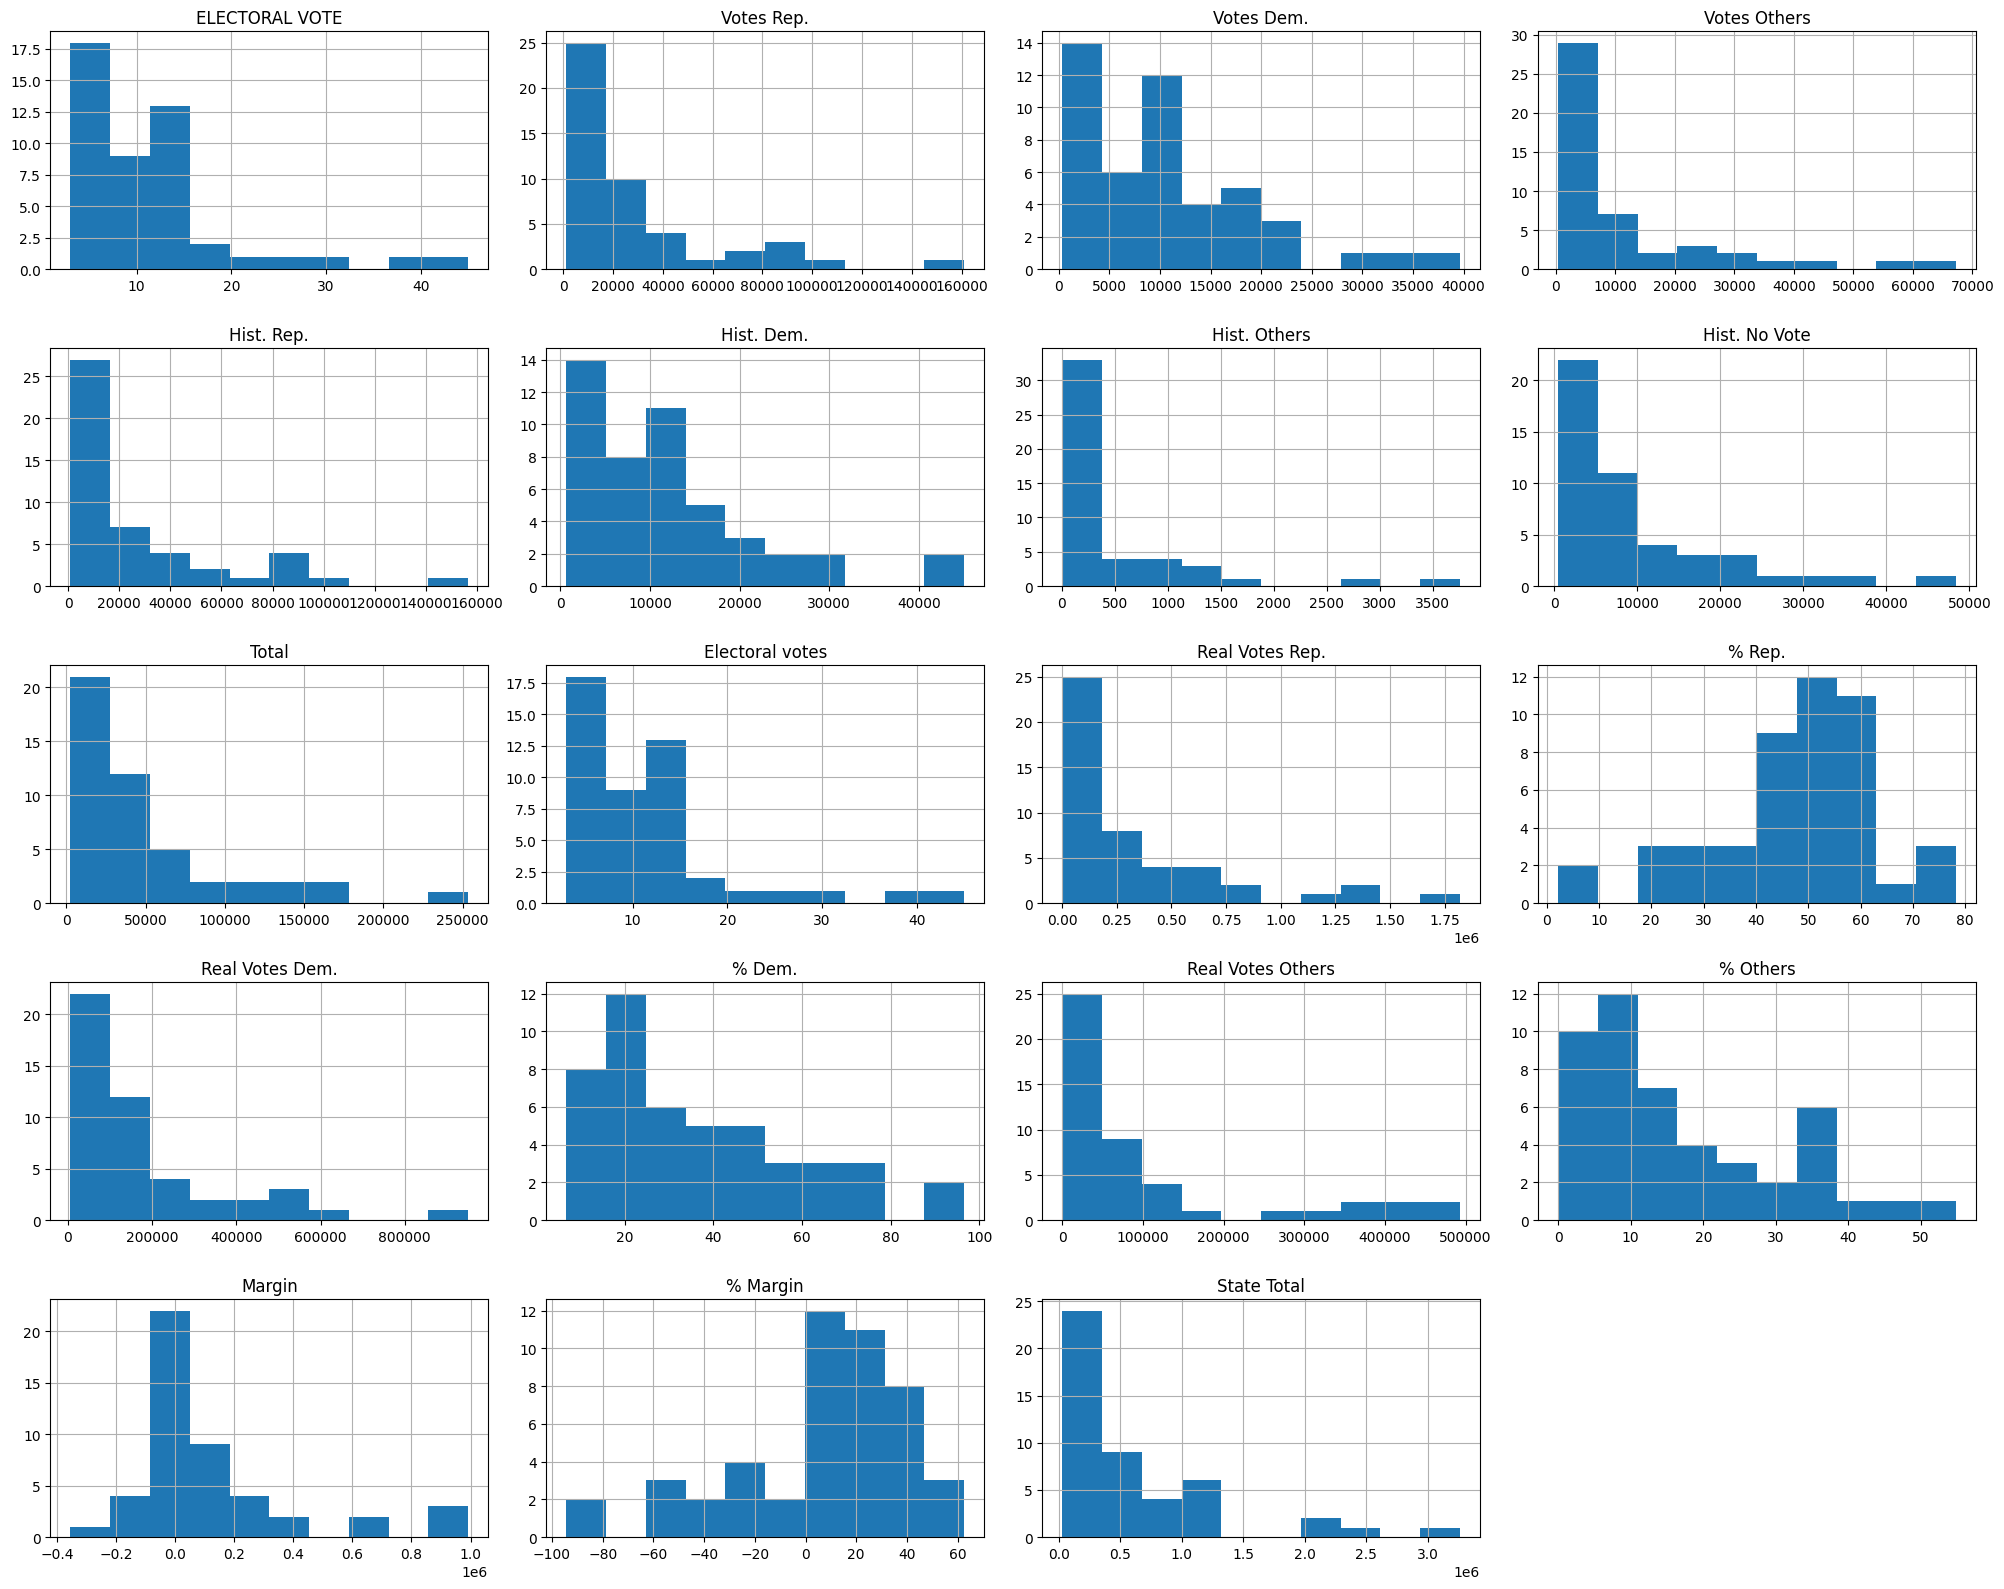

In [26]:
df_1924.hist(figsize=(20, 16))
plt.tight_layout()
plt.show()

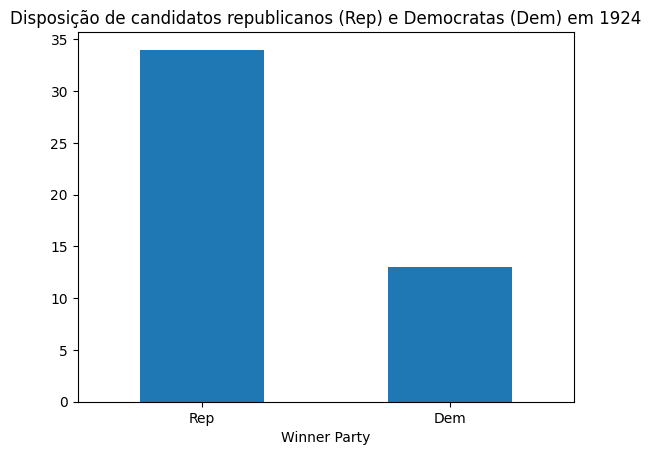

In [27]:
# Plota um gráfico de barras da distribuição do alvo(target)

df_1924["Winner Party"].value_counts().plot(kind="bar")

plt.xticks(rotation=0)
plt.title("Disposição de candidatos republicanos (Rep) e Democratas (Dem) em 1924")

plt.show()

- DataFrame 1928

In [28]:
df_1928 # Exibe o DataFrame de 1928

,Unnamed: 0,Unnamed: 1,Hoover (R),How the same voters voted in 1924,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Smith (D),How the same voters voted in 1924.1,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,VOTES FOR MINOR CANDIDATES,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,State - 1928,Electoral votes,Hoover,%,Electoral votes.1,Smith,%.1,Electoral votes.2,Thomas (Soc.),%.2,Electoral votes.3,Foster (Comm.),%.3,Electoral votes.4,Reynolds (Soc. Lab),%.4,Electoral votes.5,Margin,%.5,State total,State,Unnamed: 46
0,NaN,ELECTORAL VOTE,TOTAL 1928 VOTE,Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,NaN,TOTAL 1928 VOTE,Rep.,Dem.,soc.,F.Lab.,Proh.,No Vote,NaN,NaN,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total,NaN,Alabama,12.0,120725.0,48.49,-,127797.0,51.33,12,460,0.18,-,-,-,-,-,-,-,-7072.0,-2.84,248982.0,AL,NaN
1,ALABAMA,12,13997,4351,7221,41,1,10,2373,NaN,12298,757,9604,52,2,2,1881,NaN,NaN,ALABAMA,46,27,34,26402,NaN,Arizona,3.0,52533.0,57.57,3,38537.0,42.23,-,-,-,-,184,0.2,-,-,-,-,13996.0,15.34,91254.0,AZ,https://en.wikipedia.org/wiki/1928_United_Stat...
2,ARIZONA,3,3371,1840,936,37,0,2,556,NaN,2250,593,1197,58,4,0,398,NaN,NaN,ARIZONA,21,20,21,5683,NaN,Arkansas,9.0,77751.0,39.33,-,119196.0,60.29,9,429,0.22,-,317,0.16,-,-,-,-,-41445.0,-20.96,197693.0,AR,NaN
3,ARKANSAS,9,11652,4835,5107,44,3,4,1659,NaN,11267,963,8780,70,2,0,1452,NaN,NaN,ARKANSAS,79,28,26,23052,NaN,California,13.0,1162323.0,64.69,13,614365.0,34.19,-,19595,1.09,-,112,0.01,-,-,-,-,547958.0,30.50,1796656.0,CA,NaN
4,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,NaN,41566,22717,9766,1525,18,38,7502,NaN,NaN,CALIFORNIA,1014,447,434,132564,NaN,Colorado,6.0,253872.0,64.72,6,133131.0,33.94,-,3472,0.89,-,675,0.17,-,-,-,-,120741.0,30.78,392242.0,CO,NaN
5,COLORADO,6,16800,11236,2627,169,11,18,2739,NaN,6779,2452,2829,237,17,1,1243,NaN,NaN,COLORADO,136,74,73,23862,NaN,Connecticut,7.0,296614.0,53.63,7,252040.0,45.57,-,3019,0.55,-,730,0.13,-,622,0.11,-,44574.0,8.06,553031.0,CT,NaN
6,CONNECTICUT,7,24476,19724,1226,93,5,18,3410,NaN,10915,4665,4225,218,9,3,1795,NaN,NaN,CONNECTICUT,192,75,26,35684,NaN,Delaware,3.0,68860.0,65.03,3,36643.0,34.60,-,329,0.31,-,59,0.06,-,-,-,-,32217.0,30.42,105891.0,DE,NaN
7,DELAWARE,3,4113,2828,671,30,0,1,583,NaN,1422,356,803,26,1,0,236,NaN,NaN,DELAWARE,19,4,5,5563,NaN,Florida,6.0,144168.0,56.83,6,101764.0,40.12,-,4036,1.59,-,3704,1.46,-,-,-,-,42404.0,16.72,253672.0,FL,NaN
8,DIST. OF COLUMBIA,NaN,3765,1474,489,12,0,3,1787,NaN,2092,525,663,25,2,0,877,NaN,NaN,DIST. OF COLUMBIA,60,12,14,5943,NaN,Georgia,14.0,99369.0,43.36,-,129602.0,56.56,14,124,0.05,-,64,0.03,-,-,-,-,-30233.0,-13.19,229159.0,GA,NaN
9,FLORIDA,6,19022,7147,8753,56,1,18,3047,NaN,9951,1715,6567,58,3,4,1604,NaN,NaN,FLORIDA,65,29,33,29100,NaN,Idaho,4.0,97322.0,64.22,4,52926.0,34.93,-,1293,0.85,-,-,-,-,-,-,-,44396.0,29.30,151541.0,ID,NaN


Esse código apenas mostra a tabela completa de 1928 na tela, para dar uma primeira olhada nos dados antes de começar a tratá-los.

In [29]:
novos_nomes = {
    'Unnamed: 0': '1928 VOTE',
    'Unnamed: 1': 'ELECTORAL VOTE',
    'How the same voters voted in 1924': 'Rep.',
    'Unnamed: 4': 'Dem.',
    'Unnamed: 5': 'Soc.',
    'Unnamed: 6': 'F.Lab.',
    'Unnamed: 7': 'Proh.',
    'Unnamed: 8': 'No Vote',
    'How the same voters voted in 1924.1': 'Rep.',
    'Unnamed: 12': 'Dem.',
    'Unnamed: 13': 'Soc.',
    'Unnamed: 14': 'F.Lab.',
    'Unnamed: 15': 'Proh.',
    'Unnamed: 16': 'No Vote',
    'Unnamed: 19': 'State',
    'VOTES FOR MINOR CANDIDATES': 'Thomas (Soc.)',
    'Unnamed: 21': 'Foster (Work.)',
    'Unnamed: 22': 'Varney (Proh.)',
    'Unnamed: 23': 'Total'
} # Define novos nomes para as colunas do DataFrame

df_1928.rename(columns=novos_nomes, inplace=True) # Altera o nome das colunas de acordo com os novos nomes definidos

df_1928.head() # Exibe as 5 primeiras linhas do DataFrame

,1928 VOTE,ELECTORAL VOTE,Hoover (R),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Unnamed: 9,Smith (D),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Unnamed: 17,Unnamed: 18,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total,Unnamed: 24,State - 1928,Electoral votes,Hoover,%,Electoral votes.1,Smith,%.1,Electoral votes.2,Thomas (Soc.),%.2,Electoral votes.3,Foster (Comm.),%.3,Electoral votes.4,Reynolds (Soc. Lab),%.4,Electoral votes.5,Margin,%.5,State total,State,Unnamed: 46
0,NaN,ELECTORAL VOTE,TOTAL 1928 VOTE,Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,NaN,TOTAL 1928 VOTE,Rep.,Dem.,soc.,F.Lab.,Proh.,No Vote,NaN,NaN,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total,NaN,Alabama,12.0,120725.0,48.49,-,127797.0,51.33,12,460,0.18,-,-,-,-,-,-,-,-7072.0,-2.84,248982.0,AL,NaN
1,ALABAMA,12,13997,4351,7221,41,1,10,2373,NaN,12298,757,9604,52,2,2,1881,NaN,NaN,ALABAMA,46,27,34,26402,NaN,Arizona,3.0,52533.0,57.57,3,38537.0,42.23,-,-,-,-,184,0.2,-,-,-,-,13996.0,15.34,91254.0,AZ,https://en.wikipedia.org/wiki/1928_United_Stat...
2,ARIZONA,3,3371,1840,936,37,0,2,556,NaN,2250,593,1197,58,4,0,398,NaN,NaN,ARIZONA,21,20,21,5683,NaN,Arkansas,9.0,77751.0,39.33,-,119196.0,60.29,9,429,0.22,-,317,0.16,-,-,-,-,-41445.0,-20.96,197693.0,AR,NaN
3,ARKANSAS,9,11652,4835,5107,44,3,4,1659,NaN,11267,963,8780,70,2,0,1452,NaN,NaN,ARKANSAS,79,28,26,23052,NaN,California,13.0,1162323.0,64.69,13,614365.0,34.19,-,19595,1.09,-,112,0.01,-,-,-,-,547958.0,30.50,1796656.0,CA,NaN
4,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,NaN,41566,22717,9766,1525,18,38,7502,NaN,NaN,CALIFORNIA,1014,447,434,132564,NaN,Colorado,6.0,253872.0,64.72,6,133131.0,33.94,-,3472,0.89,-,675,0.17,-,-,-,-,120741.0,30.78,392242.0,CO,NaN


Esse bloco define nomes mais claros para as colunas do DataFrame de 1928 que vieram com nomes genéricos, tipo "Unnamed", separando as informações de votos históricos de 1924, dados eleitorais e votos de candidatos menores. Depois aplica essa renomeação e mostra as primeiras linhas da tabela já com os nomes ajustados.

In [30]:
df_1928 = df_1928.drop(columns=['Unnamed: 9', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 24', 'Unnamed: 46']) # Deletas as colunas que não oferecem valor preditivo

df_1928.head()

,1928 VOTE,ELECTORAL VOTE,Hoover (R),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Smith (D),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total,State - 1928,Electoral votes,Hoover,%,Electoral votes.1,Smith,%.1,Electoral votes.2,Thomas (Soc.),%.2,Electoral votes.3,Foster (Comm.),%.3,Electoral votes.4,Reynolds (Soc. Lab),%.4,Electoral votes.5,Margin,%.5,State total,State
0,NaN,ELECTORAL VOTE,TOTAL 1928 VOTE,Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,TOTAL 1928 VOTE,Rep.,Dem.,soc.,F.Lab.,Proh.,No Vote,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total,Alabama,12.0,120725.0,48.49,-,127797.0,51.33,12,460,0.18,-,-,-,-,-,-,-,-7072.0,-2.84,248982.0,AL
1,ALABAMA,12,13997,4351,7221,41,1,10,2373,12298,757,9604,52,2,2,1881,ALABAMA,46,27,34,26402,Arizona,3.0,52533.0,57.57,3,38537.0,42.23,-,-,-,-,184,0.2,-,-,-,-,13996.0,15.34,91254.0,AZ
2,ARIZONA,3,3371,1840,936,37,0,2,556,2250,593,1197,58,4,0,398,ARIZONA,21,20,21,5683,Arkansas,9.0,77751.0,39.33,-,119196.0,60.29,9,429,0.22,-,317,0.16,-,-,-,-,-41445.0,-20.96,197693.0,AR
3,ARKANSAS,9,11652,4835,5107,44,3,4,1659,11267,963,8780,70,2,0,1452,ARKANSAS,79,28,26,23052,California,13.0,1162323.0,64.69,13,614365.0,34.19,-,19595,1.09,-,112,0.01,-,-,-,-,547958.0,30.50,1796656.0,CA
4,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,41566,22717,9766,1525,18,38,7502,CALIFORNIA,1014,447,434,132564,Colorado,6.0,253872.0,64.72,6,133131.0,33.94,-,3472,0.89,-,675,0.17,-,-,-,-,120741.0,30.78,392242.0,CO


Aqui o código apaga colunas que não ajudam na análise ou no modelo, deixando a tabela mais limpa.

In [31]:
df_1928.shape # Exibe o formato do DataFrame (linhas, colunas)

(52, 42)

Esse código mostra quantas linhas e colunas o DataFrame de 1928 tem depois da limpeza feita até agora.

In [32]:
df_pesquisa = df_1928.iloc[:, :21]

df_pesquisa.head()

,1928 VOTE,ELECTORAL VOTE,Hoover (R),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Smith (D),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total
0,NaN,ELECTORAL VOTE,TOTAL 1928 VOTE,Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,TOTAL 1928 VOTE,Rep.,Dem.,soc.,F.Lab.,Proh.,No Vote,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total
1,ALABAMA,12,13997,4351,7221,41,1,10,2373,12298,757,9604,52,2,2,1881,ALABAMA,46,27,34,26402
2,ARIZONA,3,3371,1840,936,37,0,2,556,2250,593,1197,58,4,0,398,ARIZONA,21,20,21,5683
3,ARKANSAS,9,11652,4835,5107,44,3,4,1659,11267,963,8780,70,2,0,1452,ARKANSAS,79,28,26,23052
4,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,41566,22717,9766,1525,18,38,7502,CALIFORNIA,1014,447,434,132564


Esse código pega as primeiras 21 colunas do DataFrame, que representam os dados da pesquisa survey, e guarda em um novo DataFrame separado.

In [33]:
df_eleicao = df_1928.iloc[:, 21:]

df_eleicao.head()

,State - 1928,Electoral votes,Hoover,%,Electoral votes.1,Smith,%.1,Electoral votes.2,Thomas (Soc.),%.2,Electoral votes.3,Foster (Comm.),%.3,Electoral votes.4,Reynolds (Soc. Lab),%.4,Electoral votes.5,Margin,%.5,State total,State
0,Alabama,12.0,120725.0,48.49,-,127797.0,51.33,12,460,0.18,-,-,-,-,-,-,-,-7072.0,-2.84,248982.0,AL
1,Arizona,3.0,52533.0,57.57,3,38537.0,42.23,-,-,-,-,184,0.2,-,-,-,-,13996.0,15.34,91254.0,AZ
2,Arkansas,9.0,77751.0,39.33,-,119196.0,60.29,9,429,0.22,-,317,0.16,-,-,-,-,-41445.0,-20.96,197693.0,AR
3,California,13.0,1162323.0,64.69,13,614365.0,34.19,-,19595,1.09,-,112,0.01,-,-,-,-,547958.0,30.50,1796656.0,CA
4,Colorado,6.0,253872.0,64.72,6,133131.0,33.94,-,3472,0.89,-,675,0.17,-,-,-,-,120741.0,30.78,392242.0,CO


Aqui o código pega o restante das colunas a partir da 21, que representam os dados reais da eleição, e guarda em outro DataFrame separado.

In [34]:
df_pesquisa = df_pesquisa.shift(-1) # Sobe as linhas do DataFrame em uma posição

df_pesquisa.head(3)

,1928 VOTE,ELECTORAL VOTE,Hoover (R),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Smith (D),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total
0,ALABAMA,12,13997,4351,7221,41,1,10,2373,12298,757,9604,52,2,2,1881,ALABAMA,46,27,34,26402
1,ARIZONA,3,3371,1840,936,37,0,2,556,2250,593,1197,58,4,0,398,ARIZONA,21,20,21,5683
2,ARKANSAS,9,11652,4835,5107,44,3,4,1659,11267,963,8780,70,2,0,1452,ARKANSAS,79,28,26,23052


Esse código sobe todas as linhas do DataFrame de pesquisa uma posição para cima, provavelmente para corrigir uma desalinhação entre os dados e os nomes dos estados.

In [35]:
df_pesquisa = df_pesquisa.drop(51) # Deleta a última linha do DataFrame

df_pesquisa

,1928 VOTE,ELECTORAL VOTE,Hoover (R),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Smith (D),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,State,Thomas (Soc.),Foster (Work.),Varney (Proh.),Total
0,ALABAMA,12,13997,4351,7221,41,1,10,2373,12298,757,9604,52,2,2,1881,ALABAMA,46,27,34,26402
1,ARIZONA,3,3371,1840,936,37,0,2,556,2250,593,1197,58,4,0,398,ARIZONA,21,20,21,5683
2,ARKANSAS,9,11652,4835,5107,44,3,4,1659,11267,963,8780,70,2,0,1452,ARKANSAS,79,28,26,23052
3,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,41566,22717,9766,1525,18,38,7502,CALIFORNIA,1014,447,434,132564
4,COLORADO,6,16800,11236,2627,169,11,18,2739,6779,2452,2829,237,17,1,1243,COLORADO,136,74,73,23862
5,CONNECTICUT,7,24476,19724,1226,93,5,18,3410,10915,4665,4225,218,9,3,1795,CONNECTICUT,192,75,26,35684
6,DELAWARE,3,4113,2828,671,30,0,1,583,1422,356,803,26,1,0,236,DELAWARE,19,4,5,5563
7,DIST. OF COLUMBIA,NaN,3765,1474,489,12,0,3,1787,2092,525,663,25,2,0,877,DIST. OF COLUMBIA,60,12,14,5943
8,FLORIDA,6,19022,7147,8753,56,1,18,3047,9951,1715,6567,58,3,4,1604,FLORIDA,65,29,33,29100
9,GEORGIA,14,10507,3468,5270,71,3,2,1693,12023,787,9411,67,9,1,1748,GEORGIA,38,28,48,22644


Esse código apaga a linha de índice 51, que sobrou vazia ou incorreta depois do deslocamento feito no passo anterior.

In [36]:
df_eleicao['State - 1928'] = df_eleicao['State - 1928'].str.upper() # Define todos os registros da coluna como letras Maiúsculas
df_eleicao['State - 1928'] = df_eleicao['State - 1928'].str.strip() # Retira espaços em brancos antes e depois das palavras caso hajam

df_pesquisa['1928 VOTE'] = df_pesquisa['1928 VOTE'].str.strip()

df_eleicao = df_eleicao.rename(columns={
    'State - 1928': '1928 VOTE'
})

df_1928 = pd.merge(df_pesquisa, df_eleicao, on='1928 VOTE') # Junta os dois DataFrames criados

df_1928.head()

,1928 VOTE,ELECTORAL VOTE,Hoover (R),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Smith (D),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,State_x,Thomas (Soc.)_x,Foster (Work.),Varney (Proh.),Total,Electoral votes,Hoover,%,Electoral votes.1,Smith,%.1,Electoral votes.2,Thomas (Soc.)_y,%.2,Electoral votes.3,Foster (Comm.),%.3,Electoral votes.4,Reynolds (Soc. Lab),%.4,Electoral votes.5,Margin,%.5,State total,State_y
0,ALABAMA,12,13997,4351,7221,41,1,10,2373,12298,757,9604,52,2,2,1881,ALABAMA,46,27,34,26402,12.0,120725.0,48.49,-,127797.0,51.33,12,460,0.18,-,-,-,-,-,-,-,-7072.0,-2.84,248982.0,AL
1,ARIZONA,3,3371,1840,936,37,0,2,556,2250,593,1197,58,4,0,398,ARIZONA,21,20,21,5683,3.0,52533.0,57.57,3,38537.0,42.23,-,-,-,-,184,0.2,-,-,-,-,13996.0,15.34,91254.0,AZ
2,ARKANSAS,9,11652,4835,5107,44,3,4,1659,11267,963,8780,70,2,0,1452,ARKANSAS,79,28,26,23052,9.0,77751.0,39.33,-,119196.0,60.29,9,429,0.22,-,317,0.16,-,-,-,-,-41445.0,-20.96,197693.0,AR
3,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,41566,22717,9766,1525,18,38,7502,CALIFORNIA,1014,447,434,132564,13.0,1162323.0,64.69,13,614365.0,34.19,-,19595,1.09,-,112,0.01,-,-,-,-,547958.0,30.50,1796656.0,CA
4,COLORADO,6,16800,11236,2627,169,11,18,2739,6779,2452,2829,237,17,1,1243,COLORADO,136,74,73,23862,6.0,253872.0,64.72,6,133131.0,33.94,-,3472,0.89,-,675,0.17,-,-,-,-,120741.0,30.78,392242.0,CO


Esse código deixa todos os nomes de estados em letras maiúsculas e remove espaços em branco extras, tanto na coluna do DataFrame de eleição quanto na de pesquisa, para garantir que os textos fiquem idênticos e a junção funcione corretamente. Depois renomeia a coluna de eleição para ficar igual à de pesquisa e junta os dois DataFrames em um só, usando essa coluna em comum.

In [37]:
df_1928 = df_1928.drop(columns=['Electoral votes.2', 'Electoral votes.3', 'Electoral votes.4', 'Electoral votes.5'])

df_1928.head()

,1928 VOTE,ELECTORAL VOTE,Hoover (R),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Smith (D),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,State_x,Thomas (Soc.)_x,Foster (Work.),Varney (Proh.),Total,Electoral votes,Hoover,%,Electoral votes.1,Smith,%.1,Thomas (Soc.)_y,%.2,Foster (Comm.),%.3,Reynolds (Soc. Lab),%.4,Margin,%.5,State total,State_y
0,ALABAMA,12,13997,4351,7221,41,1,10,2373,12298,757,9604,52,2,2,1881,ALABAMA,46,27,34,26402,12.0,120725.0,48.49,-,127797.0,51.33,460,0.18,-,-,-,-,-7072.0,-2.84,248982.0,AL
1,ARIZONA,3,3371,1840,936,37,0,2,556,2250,593,1197,58,4,0,398,ARIZONA,21,20,21,5683,3.0,52533.0,57.57,3,38537.0,42.23,-,-,184,0.2,-,-,13996.0,15.34,91254.0,AZ
2,ARKANSAS,9,11652,4835,5107,44,3,4,1659,11267,963,8780,70,2,0,1452,ARKANSAS,79,28,26,23052,9.0,77751.0,39.33,-,119196.0,60.29,429,0.22,317,0.16,-,-,-41445.0,-20.96,197693.0,AR
3,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,41566,22717,9766,1525,18,38,7502,CALIFORNIA,1014,447,434,132564,13.0,1162323.0,64.69,13,614365.0,34.19,19595,1.09,112,0.01,-,-,547958.0,30.50,1796656.0,CA
4,COLORADO,6,16800,11236,2627,169,11,18,2739,6779,2452,2829,237,17,1,1243,COLORADO,136,74,73,23862,6.0,253872.0,64.72,6,133131.0,33.94,3472,0.89,675,0.17,-,-,120741.0,30.78,392242.0,CO


Esse código apaga colunas duplicadas referentes a votos eleitorais que sobraram depois da junção dos DataFrames.

In [38]:
df_1928 = df_1928.replace('-', 0)

/tmp/ipykernel_4023/3660296337.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1928 = df_1928.replace('-', 0)


Esse código troca todos os valores "-" (sem dado) pelo número 0 em toda a tabela, para não atrapalhar os cálculos.

In [39]:
lista_partidos = []

for i in range(0, 48):
  republicanos = df_1928.loc[df_1928.index[i], 'Hoover']
  democratas = df_1928.loc[df_1928.index[i], 'Smith']

  partidos = np.array([republicanos, democratas])

  vencedor = partidos.max()

  if vencedor == republicanos:
    partido_vencedor = 'Rep'
  elif vencedor == democratas:
    partido_vencedor = 'Dem'

  lista_partidos.append(partido_vencedor)

df_1928['Winner Party'] = lista_partidos

df_1928

,1928 VOTE,ELECTORAL VOTE,Hoover (R),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,Smith (D),Rep.,Dem.,Soc.,F.Lab.,Proh.,No Vote,State_x,Thomas (Soc.)_x,Foster (Work.),Varney (Proh.),Total,Electoral votes,Hoover,%,Electoral votes.1,Smith,%.1,Thomas (Soc.)_y,%.2,Foster (Comm.),%.3,Reynolds (Soc. Lab),%.4,Margin,%.5,State total,State_y,Winner Party
0,ALABAMA,12,13997,4351,7221,41,1,10,2373,12298,757,9604,52,2,2,1881,ALABAMA,46,27,34,26402,12.0,120725.0,48.49,0,127797.0,51.33,460,0.18,0,0.00,0,0.00,-7072.0,-2.84,248982.0,AL,Dem
1,ARIZONA,3,3371,1840,936,37,0,2,556,2250,593,1197,58,4,0,398,ARIZONA,21,20,21,5683,3.0,52533.0,57.57,3,38537.0,42.23,0,0.00,184,0.20,0,0.00,13996.0,15.34,91254.0,AZ,Rep
2,ARKANSAS,9,11652,4835,5107,44,3,4,1659,11267,963,8780,70,2,0,1452,ARKANSAS,79,28,26,23052,9.0,77751.0,39.33,0,119196.0,60.29,429,0.22,317,0.16,0,0.00,-41445.0,-20.96,197693.0,AR,Dem
3,CALIFORNIA,13,89103,62283,10686,1113,19,463,14539,41566,22717,9766,1525,18,38,7502,CALIFORNIA,1014,447,434,132564,13.0,1162323.0,64.69,13,614365.0,34.19,19595,1.09,112,0.01,0,0.00,547958.0,30.50,1796656.0,CA,Rep
4,COLORADO,6,16800,11236,2627,169,11,18,2739,6779,2452,2829,237,17,1,1243,COLORADO,136,74,73,23862,6.0,253872.0,64.72,6,133131.0,33.94,3472,0.89,675,0.17,0,0.00,120741.0,30.78,392242.0,CO,Rep
5,CONNECTICUT,7,24476,19724,1226,93,5,18,3410,10915,4665,4225,218,9,3,1795,CONNECTICUT,192,75,26,35684,7.0,296614.0,53.63,7,252040.0,45.57,3019,0.55,730,0.13,622,0.11,44574.0,8.06,553031.0,CT,Rep
6,DELAWARE,3,4113,2828,671,30,0,1,583,1422,356,803,26,1,0,236,DELAWARE,19,4,5,5563,3.0,68860.0,65.03,3,36643.0,34.60,329,0.31,59,0.06,0,0.00,32217.0,30.42,105891.0,DE,Rep
7,FLORIDA,6,19022,7147,8753,56,1,18,3047,9951,1715,6567,58,3,4,1604,FLORIDA,65,29,33,29100,6.0,144168.0,56.83,6,101764.0,40.12,4036,1.59,3704,1.46,0,0.00,42404.0,16.72,253672.0,FL,Rep
8,GEORGIA,14,10507,3468,5270,71,3,2,1693,12023,787,9411,67,9,1,1748,GEORGIA,38,28,48,22644,14.0,99369.0,43.36,0,129602.0,56.56,124,0.05,64,0.03,0,0.00,-30233.0,-13.19,229159.0,GA,Dem
9,IDAHO,4,6038,4224,642,166,0,3,1003,3005,1301,1008,179,4,0,513,IDAHO,92,30,29,9194,4.0,97322.0,64.22,4,52926.0,34.93,1293,0.85,0,0.00,0,0.00,44396.0,29.30,151541.0,ID,Rep


Esse bloco percorre cada linha do DataFrame, compara os votos entre Hoover e Smith e descobre qual candidato venceu em cada estado, guardando o resultado em uma lista. No final, cria uma nova coluna "Winner Party" com esse resultado.

In [40]:
cols = []
count = {}

for col in df_1928.columns:
  if col in count:
    count[col] += 1
    cols.append(f'{col}.{count[col]}')
  else:
    count[col] = 0
    cols.append(col)

df_1928.columns = cols

novos_nomes = {
    '1928 VOTE': 'State',
    'Hoover (R)': 'Votes Rep.',
    'Smith (D)': 'Votes Dem.',
    'Thomas (Soc.)_x': 'Votes Others',
    'Rep.': 'Hist. Rep.',
    'Dem.': 'Hist. Dem.',
    'Soc.': 'Hist. Others',
    'No Vote': 'Hist. No Vote',
    'Hoover': 'Real Votes Rep.',
    '%': '% Rep.',
    'Smith': 'Real Votes Dem.',
    '%.1': '% Dem.',
    'Thomas (Soc.)_y': 'Real Votes Others',
    '%.2': '% Others',
    '%.5': '% Margin',
    'State total': 'State Total'
}

df_1928.rename(columns=novos_nomes, inplace=True)

df_1928['Votes Others'] = df_1928['Votes Others'] + df_1928['Foster (Work.)'] + df_1928['Varney (Proh.)']
df_1928['Hist. Others'] = df_1928['Hist. Others'] + df_1928['F.Lab.'] + df_1928['Proh.'] + df_1928['Soc..1'] + df_1928['F.Lab..1'] + df_1928['Proh..1']
df_1928['Hist. Rep.'] = df_1928['Hist. Rep.'] + df_1928['Rep..1']
df_1928['Hist. Dem.'] = df_1928['Hist. Dem.'] + df_1928['Dem..1']
df_1928['Hist. No Vote'] = df_1928['Hist. No Vote'] + df_1928['No Vote.1']
df_1928['Real Votes Others'] = df_1928['Real Votes Others'] + df_1928['Foster (Comm.)'] + df_1928['Reynolds (Soc. Lab)']
df_1928['% Others'] = df_1928['% Others'] + df_1928['%.3'] + df_1928['%.4']

df_1928 = df_1928.drop(columns=['Foster (Work.)', 'Varney (Proh.)', 'F.Lab.', 'Proh.', 'Rep..1', 'Dem..1', 'Soc..1', 'F.Lab..1', 'Proh..1', '%.3', '%.4', 'No Vote.1', 'Electoral votes.1', 'Foster (Comm.)', 'Reynolds (Soc. Lab)', 'State_x', 'State_y'])

df_1928.head()

,State,ELECTORAL VOTE,Votes Rep.,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Votes Dem.,Votes Others,Total,Electoral votes,Real Votes Rep.,% Rep.,Real Votes Dem.,% Dem.,Real Votes Others,% Others,Margin,% Margin,State Total,Winner Party
0,ALABAMA,12,13997,5108,16825,108,4254,12298,107,26402,12.0,120725.0,48.49,127797.0,51.33,460,0.18,-7072.0,-2.84,248982.0,Dem
1,ARIZONA,3,3371,2433,2133,101,954,2250,62,5683,3.0,52533.0,57.57,38537.0,42.23,184,0.20,13996.0,15.34,91254.0,Rep
2,ARKANSAS,9,11652,5798,13887,123,3111,11267,133,23052,9.0,77751.0,39.33,119196.0,60.29,746,0.38,-41445.0,-20.96,197693.0,Dem
3,CALIFORNIA,13,89103,85000,20452,3176,22041,41566,1895,132564,13.0,1162323.0,64.69,614365.0,34.19,19707,1.10,547958.0,30.50,1796656.0,Rep
4,COLORADO,6,16800,13688,5456,453,3982,6779,283,23862,6.0,253872.0,64.72,133131.0,33.94,4147,1.06,120741.0,30.78,392242.0,Rep


Esse bloco primeiro identifica colunas com nomes repetidos e adiciona um sufixo numérico para diferenciá-las, evitando conflitos. Depois renomeia as colunas para nomes mais organizados, separando dados de pesquisa, histórico e resultado real. Em seguida, soma os votos de candidatos menores em uma única coluna "Others" tanto votos quanto porcentagens, incluindo os dados históricos, e por fim remove as colunas que já foram somadas e não são mais necessárias.

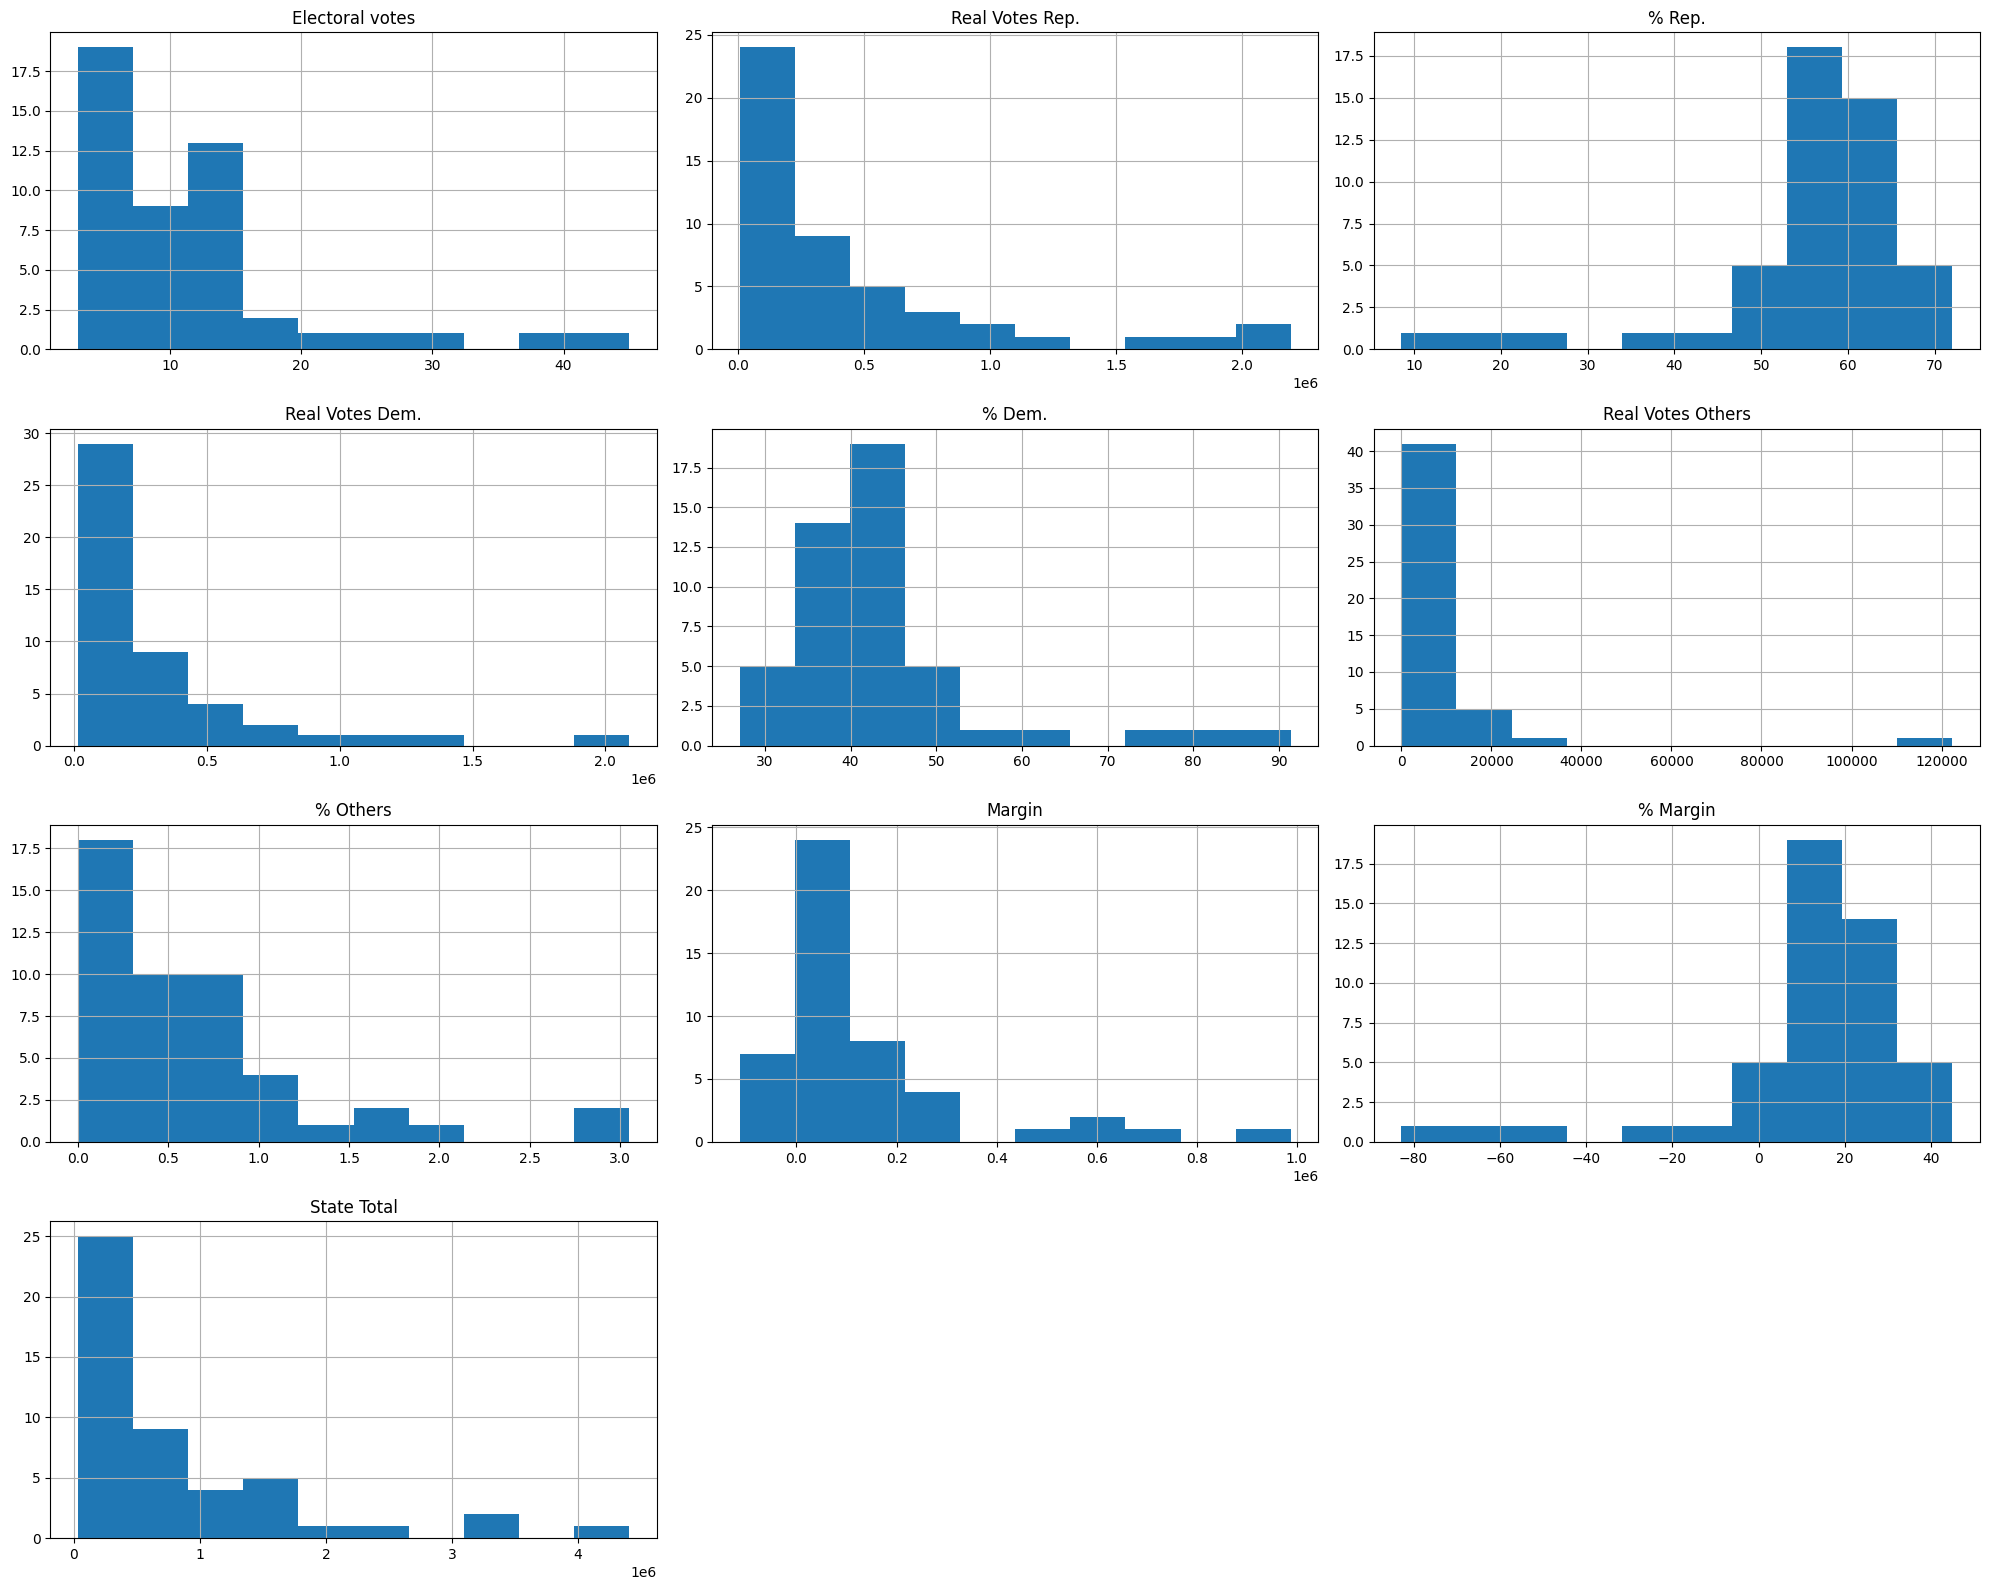

In [41]:
df_1928.hist(figsize=(20, 16))
plt.tight_layout()
plt.show()

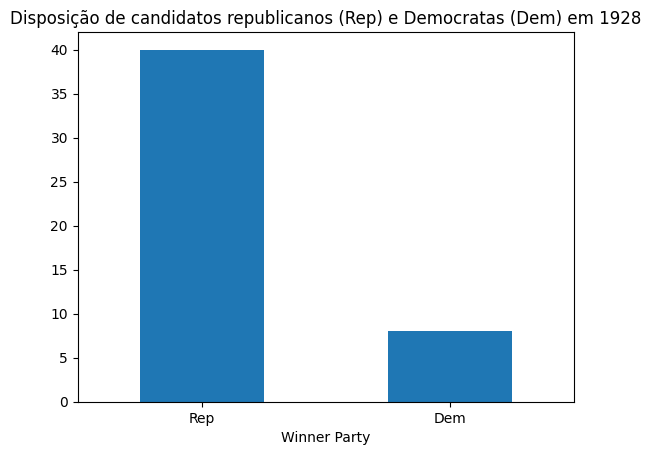

In [42]:
# Plota um gráfico de barras da distribuição do alvo(target)

df_1928["Winner Party"].value_counts().plot(kind="bar")

plt.xticks(rotation=0)
plt.title("Disposição de candidatos republicanos (Rep) e Democratas (Dem) em 1928")

plt.show()

- DataFrame 1932

In [43]:
df_pesquisa = df_1932.iloc[:, :27]
df_eleicao  = df_1932.iloc[:, 27:]

# a linha 0 do bloco de pesquisa traz os nomes reais das colunas
novos_nomes = df_pesquisa.iloc[0].to_dict()
novos_nomes['Unnamed: 0'] = 'State'   # essa coluna nao tem rotulo na linha 0
df_pesquisa = df_pesquisa.rename(columns=novos_nomes)
df_pesquisa = df_pesquisa.drop(index=0).reset_index(drop=True)

# remove colunas separadoras vazias (sem nome)
df_pesquisa = df_pesquisa.loc[:, df_pesquisa.columns.notna()]

# padroniza para bater com o bloco de eleicao
df_pesquisa['State'] = df_pesquisa['State'].str.title()

df_pesquisa.head()

,State,Electoral Votes,1932 Total Vote,Rep.,Dem.,Other,Did Not Vote,1932 Total Vote,Rep.,Dem.,Other,Did Not Vote,Thomas,Reynolds,Coxey,Upshaw,Foster,Miscellaneous,Totals,Total
0,Alabama,11,4272,3150,480,1,641,20161,3183,13629,4,3345,402,1,21,213,33,43,713,25146
1,Arizona,3,2574,2022,218,1,333,4910,1597,2581,2,730,254,1,18,53,21,15,362,7846
2,Arkansas,9,3712,2997,250,1,464,16225,2414,11564,5,2242,225,3,7,160,16,47,458,20395
3,California,22,81834,67017,3847,99,10871,148832,77197,50252,340,21043,7874,115,213,1099,1444,565,11310,241976
4,Colorado,6,11950,9870,603,4,1473,14304,5730,6408,32,2134,1546,12,40,155,123,102,1978,28232


Esse bloco divide o DataFrame de 1932 em duas partes: pesquisa 27 primeiras colunas e eleição o restante. Como os nomes reais das colunas de pesquisa estão na primeira linha da tabela e não no cabeçalho, o código pega essa linha, transforma em um dicionário de nomes e renomeia as colunas com base nele, além de nomear manualmente a coluna sem rótulo como "State". Depois apaga essa linha de nomes que já cumpriu sua função e reorganiza os índices. Em seguida, remove colunas vazias que serviam só de separador visual, e por fim deixa o texto da coluna "State" no padrão de título primeira letra maiúscula para poder bater com o outro DataFrame mais tarde.

In [44]:
df_eleicao = df_eleicao.drop(columns=['Unnamed: 44'])
df_eleicao = df_eleicao.rename(columns={'State - 1932': 'State'})

df_eleicao.head()

,State,Electoral votes,Roosevelt,%,Electoral votes.1,Hoover,%.1,Electoral votes.2,Thomas (Soc.),%.2,Electoral votes.3,Other,%.3,Electoral votes.4,Margin,%.4,Total votes
0,Alabama,11.0,207910.0,84.74,11,34675.0,14.13,–,2030.0,0.83,–,739.0,0.30,–,173235,70.61,245354.0
1,Arizona,3.0,79264.0,67.03,3,36104.0,30.53,–,2618.0,2.21,–,265.0,0.22,–,43160,36.5,118251.0
2,Arkansas,9.0,189602.0,85.96,9,28467.0,12.91,–,1269.0,0.58,–,1224.0,0.55,–,161135,73.06,220562.0
3,California,22.0,1324157.0,58.39,22,847902.0,37.39,–,63299.0,2.79,–,32608.0,1.44,–,476255,21,2267966.0
4,Colorado,6.0,250877.0,54.81,6,189617.0,41.43,–,13591.0,2.97,–,3611.0,0.79,–,61260,13.38,457696.0


Esse código remove uma coluna sem valor útil do bloco de eleição e renomeia a coluna dos estados para "State", deixando o nome igual ao do DataFrame de pesquisa.

In [45]:
df_pesquisa.loc[df_pesquisa.index[50], 'State'] = 'TOTALS:'
df_eleicao.loc[df_eleicao.index[48], 'State'] = 'TOTALS:'

df_1932 = pd.merge(df_pesquisa, df_eleicao, on='State')

df_1932

,State,Electoral Votes,1932 Total Vote,Rep.,Dem.,Other_x,Did Not Vote,1932 Total Vote,Rep.,Dem.,Other_x,Did Not Vote,Thomas,Reynolds,Coxey,Upshaw,Foster,Miscellaneous,Totals,Total,Electoral votes,Roosevelt,%,Electoral votes.1,Hoover,%.1,Electoral votes.2,Thomas (Soc.),%.2,Electoral votes.3,Other_y,%.3,Electoral votes.4,Margin,%.4,Total votes
0,Alabama,11,4272,3150,480,1,641,20161,3183,13629,4,3345,402,1,21,213,33,43,713,25146,11.0,207910.0,84.74,11,34675.0,14.13,–,2030.0,0.83,–,739.0,0.30,–,173235,70.61,245354.0
1,Arizona,3,2574,2022,218,1,333,4910,1597,2581,2,730,254,1,18,53,21,15,362,7846,3.0,79264.0,67.03,3,36104.0,30.53,–,2618.0,2.21,–,265.0,0.22,–,43160,36.5,118251.0
2,Arkansas,9,3712,2997,250,1,464,16225,2414,11564,5,2242,225,3,7,160,16,47,458,20395,9.0,189602.0,85.96,9,28467.0,12.91,–,1269.0,0.58,–,1224.0,0.55,–,161135,73.06,220562.0
3,California,22,81834,67017,3847,99,10871,148832,77197,50252,340,21043,7874,115,213,1099,1444,565,11310,241976,22.0,1324157.0,58.39,22,847902.0,37.39,–,63299.0,2.79,–,32608.0,1.44,–,476255,21,2267966.0
4,Colorado,6,11950,9870,603,4,1473,14304,5730,6408,32,2134,1546,12,40,155,123,102,1978,28232,6.0,250877.0,54.81,6,189617.0,41.43,–,13591.0,2.97,–,3611.0,0.79,–,61260,13.38,457696.0
5,Connecticut,8,26469,21590,1539,9,3331,16884,5521,8966,27,2370,4256,61,44,82,199,225,4867,48220,8.0,281632.0,47.40,–,288420.0,48.54,8,20480.0,3.45,–,3651.0,0.61,–,"−6,788",−1.14,594183.0
6,Delaware,3,2384,1809,229,0,346,2546,800,1308,7,431,205,1,3,30,17,23,279,5209,3.0,54319.0,48.11,–,57073.0,50.55,3,1376.0,1.22,–,133.0,0.12,–,"−2,754",−2.44,112901.0
7,Florida,7,9302,6944,880,3,1475,23606,6393,13411,5,3797,857,8,32,408,86,100,1491,34399,7.0,206307.0,74.68,7,69170.0,25.04,–,775.0,0.28,–,0.0,0.00,–,137137,49.64,276252.0
8,Georgia,12,4823,3465,499,2,857,31849,5778,20512,6,5553,329,12,14,407,39,71,872,37544,12.0,234118.0,91.60,12,19863.0,7.77,–,461.0,0.18,–,1148.0,0.45,–,214255,83.83,255590.0
9,Idaho,4,3282,2649,211,3,419,5159,2177,2212,9,761,307,8,24,80,29,193,641,9082,4.0,109479.0,58.66,4,71417.0,38.27,–,526.0,0.28,–,5203.0,2.79,–,38062,20.39,186625.0


Esse código substitui o valor da linha de totais em cada DataFrame pesquisa e eleição por "TOTALS:", garantindo que as duas tabelas tenham essa referência igual. Depois junta os dois DataFrames em um só, usando a coluna "State" como referência.

In [46]:
df_1932.isna().sum()

,0
State,0
Electoral Votes,0
1932 Total Vote,0
Rep.,0
Dem.,0
Other_x,0
Did Not Vote,0
1932 Total Vote,0
Rep.,0
Dem.,0


Esse código verifica se sobraram valores nulos no DataFrame de 1932 depois da junção, para conferir se está tudo certo antes de seguir com o tratamento dos dados.

In [47]:
df_1932['Electoral votes.4'] = df_1932['Electoral votes.1'].replace('–', 0)
df_1932['Electoral votes.2'] = df_1932['Electoral votes.2'].replace('–', 0)
df_1932['Electoral votes.3'] = df_1932['Electoral votes.3'].replace('–', 0)
df_1932['Electoral votes.4'] = df_1932['Electoral votes.4'].replace('–', 0)

/tmp/ipykernel_4023/3687140163.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1932['Electoral votes.4'] = df_1932['Electoral votes.1'].replace('–', 0)
/tmp/ipykernel_4023/3687140163.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1932['Electoral votes.2'] = df_1932['Electoral votes.2'].replace('–', 0)
/tmp/ipykernel_4023/3687140163.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

Esse código troca o traço "–" que representa dado ausente pelo número 0 em quatro colunas de votos eleitorais, garantindo que elas fiquem prontas para serem usadas em cálculos.

In [48]:
df_1932 = df_1932.drop(columns=['Electoral votes.4', 'Electoral votes.3'])
df_1932.head()

,State,Electoral Votes,1932 Total Vote,Rep.,Dem.,Other_x,Did Not Vote,1932 Total Vote,Rep.,Dem.,Other_x,Did Not Vote,Thomas,Reynolds,Coxey,Upshaw,Foster,Miscellaneous,Totals,Total,Electoral votes,Roosevelt,%,Electoral votes.1,Hoover,%.1,Electoral votes.2,Thomas (Soc.),%.2,Other_y,%.3,Margin,%.4,Total votes
0,Alabama,11,4272,3150,480,1,641,20161,3183,13629,4,3345,402,1,21,213,33,43,713,25146,11.0,207910.0,84.74,11,34675.0,14.13,0,2030.0,0.83,739.0,0.30,173235,70.61,245354.0
1,Arizona,3,2574,2022,218,1,333,4910,1597,2581,2,730,254,1,18,53,21,15,362,7846,3.0,79264.0,67.03,3,36104.0,30.53,0,2618.0,2.21,265.0,0.22,43160,36.5,118251.0
2,Arkansas,9,3712,2997,250,1,464,16225,2414,11564,5,2242,225,3,7,160,16,47,458,20395,9.0,189602.0,85.96,9,28467.0,12.91,0,1269.0,0.58,1224.0,0.55,161135,73.06,220562.0
3,California,22,81834,67017,3847,99,10871,148832,77197,50252,340,21043,7874,115,213,1099,1444,565,11310,241976,22.0,1324157.0,58.39,22,847902.0,37.39,0,63299.0,2.79,32608.0,1.44,476255,21,2267966.0
4,Colorado,6,11950,9870,603,4,1473,14304,5730,6408,32,2134,1546,12,40,155,123,102,1978,28232,6.0,250877.0,54.81,6,189617.0,41.43,0,13591.0,2.97,3611.0,0.79,61260,13.38,457696.0


Esse código apaga duas colunas de votos eleitorais que ficaram redundantes depois do tratamento anterior.

In [49]:
lista_partidos = []

for i in range(0, 49):
  republicanos = pd.to_numeric(df_1932.loc[df_1932.index[i], 'Hoover'], errors='coerce')
  democratas = pd.to_numeric(df_1932.loc[df_1932.index[i], 'Roosevelt'], errors='coerce')
  socialistas = pd.to_numeric(df_1932.loc[df_1932.index[i], 'Thomas (Soc.)'], errors='coerce')

  partidos = np.array([republicanos, democratas, socialistas])

  vencedor = partidos.max()

  if vencedor == republicanos:
    partido_vencedor = 'Rep'
  elif vencedor == democratas:
    partido_vencedor = 'Dem'
  elif vencedor == socialistas:
    partido_vencedor = 'Soc'

  lista_partidos.append(partido_vencedor)

df_1932['Winner Party'] = lista_partidos

df_1932

,State,Electoral Votes,1932 Total Vote,Rep.,Dem.,Other_x,Did Not Vote,1932 Total Vote,Rep.,Dem.,Other_x,Did Not Vote,Thomas,Reynolds,Coxey,Upshaw,Foster,Miscellaneous,Totals,Total,Electoral votes,Roosevelt,%,Electoral votes.1,Hoover,%.1,Electoral votes.2,Thomas (Soc.),%.2,Other_y,%.3,Margin,%.4,Total votes,Winner Party
0,Alabama,11,4272,3150,480,1,641,20161,3183,13629,4,3345,402,1,21,213,33,43,713,25146,11.0,207910.0,84.74,11,34675.0,14.13,0,2030.0,0.83,739.0,0.30,173235,70.61,245354.0,Dem
1,Arizona,3,2574,2022,218,1,333,4910,1597,2581,2,730,254,1,18,53,21,15,362,7846,3.0,79264.0,67.03,3,36104.0,30.53,0,2618.0,2.21,265.0,0.22,43160,36.5,118251.0,Dem
2,Arkansas,9,3712,2997,250,1,464,16225,2414,11564,5,2242,225,3,7,160,16,47,458,20395,9.0,189602.0,85.96,9,28467.0,12.91,0,1269.0,0.58,1224.0,0.55,161135,73.06,220562.0,Dem
3,California,22,81834,67017,3847,99,10871,148832,77197,50252,340,21043,7874,115,213,1099,1444,565,11310,241976,22.0,1324157.0,58.39,22,847902.0,37.39,0,63299.0,2.79,32608.0,1.44,476255,21,2267966.0,Dem
4,Colorado,6,11950,9870,603,4,1473,14304,5730,6408,32,2134,1546,12,40,155,123,102,1978,28232,6.0,250877.0,54.81,6,189617.0,41.43,0,13591.0,2.97,3611.0,0.79,61260,13.38,457696.0,Dem
5,Connecticut,8,26469,21590,1539,9,3331,16884,5521,8966,27,2370,4256,61,44,82,199,225,4867,48220,8.0,281632.0,47.40,–,288420.0,48.54,8,20480.0,3.45,3651.0,0.61,"−6,788",−1.14,594183.0,Rep
6,Delaware,3,2384,1809,229,0,346,2546,800,1308,7,431,205,1,3,30,17,23,279,5209,3.0,54319.0,48.11,–,57073.0,50.55,3,1376.0,1.22,133.0,0.12,"−2,754",−2.44,112901.0,Rep
7,Florida,7,9302,6944,880,3,1475,23606,6393,13411,5,3797,857,8,32,408,86,100,1491,34399,7.0,206307.0,74.68,7,69170.0,25.04,0,775.0,0.28,0.0,0.00,137137,49.64,276252.0,Dem
8,Georgia,12,4823,3465,499,2,857,31849,5778,20512,6,5553,329,12,14,407,39,71,872,37544,12.0,234118.0,91.60,12,19863.0,7.77,0,461.0,0.18,1148.0,0.45,214255,83.83,255590.0,Dem
9,Idaho,4,3282,2649,211,3,419,5159,2177,2212,9,761,307,8,24,80,29,193,641,9082,4.0,109479.0,58.66,4,71417.0,38.27,0,526.0,0.28,5203.0,2.79,38062,20.39,186625.0,Dem


Esse bloco percorre cada linha do DataFrame, transforma os votos de Hoover, Roosevelt e Thomas em números tratando erros de conversão como valores nulos, e compara os três para descobrir qual partido teve mais votos em cada estado. O resultado é guardado em uma lista e depois vira uma nova coluna "Winner Party" no DataFrame.

In [50]:
cols = []
count = {}

for col in df_1932.columns:
  if col in count:
    count[col] += 1
    cols.append(f'{col}.{count[col]}')
  else:
    count[col] = 0
    cols.append(col)

df_1932.columns = cols

novos_nomes = {
    'Electoral Votes': 'ELECTORAL VOTE',
    '1932 Total Vote': 'Votes Rep.',
    '1932 Total Vote.1': 'Votes Dem.',
    'Thomas': 'Votes Others',
    'Rep.': 'Hist. Rep.',
    'Dem.': 'Hist. Dem.',
    'Other_x': 'Hist. Others',
    'Did Not Vote': 'Hist. No Vote',
    'Hoover': 'Real Votes Rep.',
    '%.1': '% Rep.',
    'Roosevelt': 'Real Votes Dem.',
    '%': '% Dem.',
    'Thomas (Soc.)': 'Real Votes Others',
    '%.2': '% Others',
    '%.4': '% Margin',
    'Total votes': 'State Total'
}

df_1932.rename(columns=novos_nomes, inplace=True)

df_1932['Votes Others'] = df_1932['Votes Others'] + df_1932['Reynolds'] + df_1932['Coxey'] + df_1932['Upshaw'] + df_1932['Foster'] + df_1932['Miscellaneous']
df_1932['Hist. Others'] = df_1932['Hist. Others'] + df_1932['Other_x.1']
df_1932['Hist. Rep.'] = df_1932['Hist. Rep.'] + df_1932['Rep..1']
df_1932['Hist. Dem.'] = df_1932['Hist. Dem.'] + df_1932['Dem..1']
df_1932['Hist. No Vote'] = df_1932['Hist. No Vote'] + df_1932['Did Not Vote.1']
df_1932['Real Votes Others'] = df_1932['Real Votes Others'] + df_1932['Other_y']
df_1932['% Others'] = df_1932['% Others'] + df_1932['%.3']

df_1932 = df_1932.drop(columns=['Reynolds', 'Coxey', 'Upshaw', 'Foster', 'Miscellaneous', 'Rep..1', 'Dem..1', 'Did Not Vote.1', 'Other_y', '%.3', 'Other_x.1', 'Totals', 'Electoral votes.1', 'Electoral votes.2'])

df_1932.head()

,State,ELECTORAL VOTE,Votes Rep.,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Votes Dem.,Votes Others,Total,Electoral votes,Real Votes Dem.,% Dem.,Real Votes Rep.,% Rep.,Real Votes Others,% Others,Margin,% Margin,State Total,Winner Party
0,Alabama,11,4272,6333,14109,5,3986,20161,713,25146,11.0,207910.0,84.74,34675.0,14.13,2769.0,1.13,173235,70.61,245354.0,Dem
1,Arizona,3,2574,3619,2799,3,1063,4910,362,7846,3.0,79264.0,67.03,36104.0,30.53,2883.0,2.43,43160,36.5,118251.0,Dem
2,Arkansas,9,3712,5411,11814,6,2706,16225,458,20395,9.0,189602.0,85.96,28467.0,12.91,2493.0,1.13,161135,73.06,220562.0,Dem
3,California,22,81834,144214,54099,439,31914,148832,11310,241976,22.0,1324157.0,58.39,847902.0,37.39,95907.0,4.23,476255,21,2267966.0,Dem
4,Colorado,6,11950,15600,7011,36,3607,14304,1978,28232,6.0,250877.0,54.81,189617.0,41.43,17202.0,3.76,61260,13.38,457696.0,Dem


Esse bloco primeiro identifica colunas com nomes repetidos e adiciona um sufixo numérico para diferenciá-las. Depois renomeia as colunas para nomes mais organizados, separando dados de pesquisa, histórico e resultado real. Em seguida, soma os votos de candidatos menores em uma única coluna "Others" incluindo votos, histórico e porcentagens, e por fim remove as colunas que já foram somadas e não são mais necessárias, deixando a tabela mais limpa.

In [51]:
df_1932 = df_1932.drop(48)

df_1932.tail()

,State,ELECTORAL VOTE,Votes Rep.,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Votes Dem.,Votes Others,Total,Electoral votes,Real Votes Dem.,% Dem.,Real Votes Rep.,% Rep.,Real Votes Others,% Others,Margin,% Margin,State Total,Winner Party
43,Virginia,11,13440,17994,22248,25,7364,34191,1609,49240,11.0,203979.0,68.46,89637.0,30.09,4326.0,1.45,114342,38.38,297942.0,Dem
44,Washington,8,16717,28682,11534,50,6775,30324,2776,49817,8.0,353260.0,57.46,208645.0,33.94,52909.0,8.61,144615,23.52,614814.0,Dem
45,West Virginia,8,14365,18550,14358,27,4583,23153,1177,38695,8.0,405124.0,54.47,330731.0,44.47,7919.0,1.06,74393,10,743774.0,Dem
46,Wisconsin,12,21375,37038,19353,181,8857,44054,5047,70476,12.0,707410.0,63.46,347741.0,31.19,59657.0,5.35,359669,32.26,1114808.0,Dem
47,Wyoming,3,2201,2994,1419,6,695,2913,327,5441,3.0,54370.0,56.07,39583.0,40.82,3009.0,3.11,14787,15.25,96962.0,Dem


Esse código apaga a linha de índice 48, que corresponde à linha "TOTALS" do DataFrame de 1932, já que ela não representa um estado de verdade.

In [52]:
df_1932.shape

(48, 21)

Esse código mostra quantas linhas e colunas restaram no DataFrame de 1932 depois de toda a limpeza feita até agora.

In [53]:
sorted(df_1932.columns)

['% Dem.',
 '% Margin',
 '% Others',
 '% Rep.',
 'ELECTORAL VOTE',
 'Electoral votes',
 'Hist. Dem.',
 'Hist. No Vote',
 'Hist. Others',
 'Hist. Rep.',
 'Margin',
 'Real Votes Dem.',
 'Real Votes Others',
 'Real Votes Rep.',
 'State',
 'State Total',
 'Total',
 'Votes Dem.',
 'Votes Others',
 'Votes Rep.',
 'Winner Party']

Esse código mostra o nome de todas as colunas do DataFrame de 1932 organizadas em ordem alfabética, ajudando a conferir se tudo ficou nomeado corretamente.

In [54]:
df_1932.head(2)

,State,ELECTORAL VOTE,Votes Rep.,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Votes Dem.,Votes Others,Total,Electoral votes,Real Votes Dem.,% Dem.,Real Votes Rep.,% Rep.,Real Votes Others,% Others,Margin,% Margin,State Total,Winner Party
0,Alabama,11,4272,6333,14109,5,3986,20161,713,25146,11.0,207910.0,84.74,34675.0,14.13,2769.0,1.13,173235,70.61,245354.0,Dem
1,Arizona,3,2574,3619,2799,3,1063,4910,362,7846,3.0,79264.0,67.03,36104.0,30.53,2883.0,2.43,43160,36.5,118251.0,Dem


Esse código mostra as duas primeiras linhas do DataFrame de 1932, para dar uma conferida final em como a tabela ficou depois de todo o tratamento.

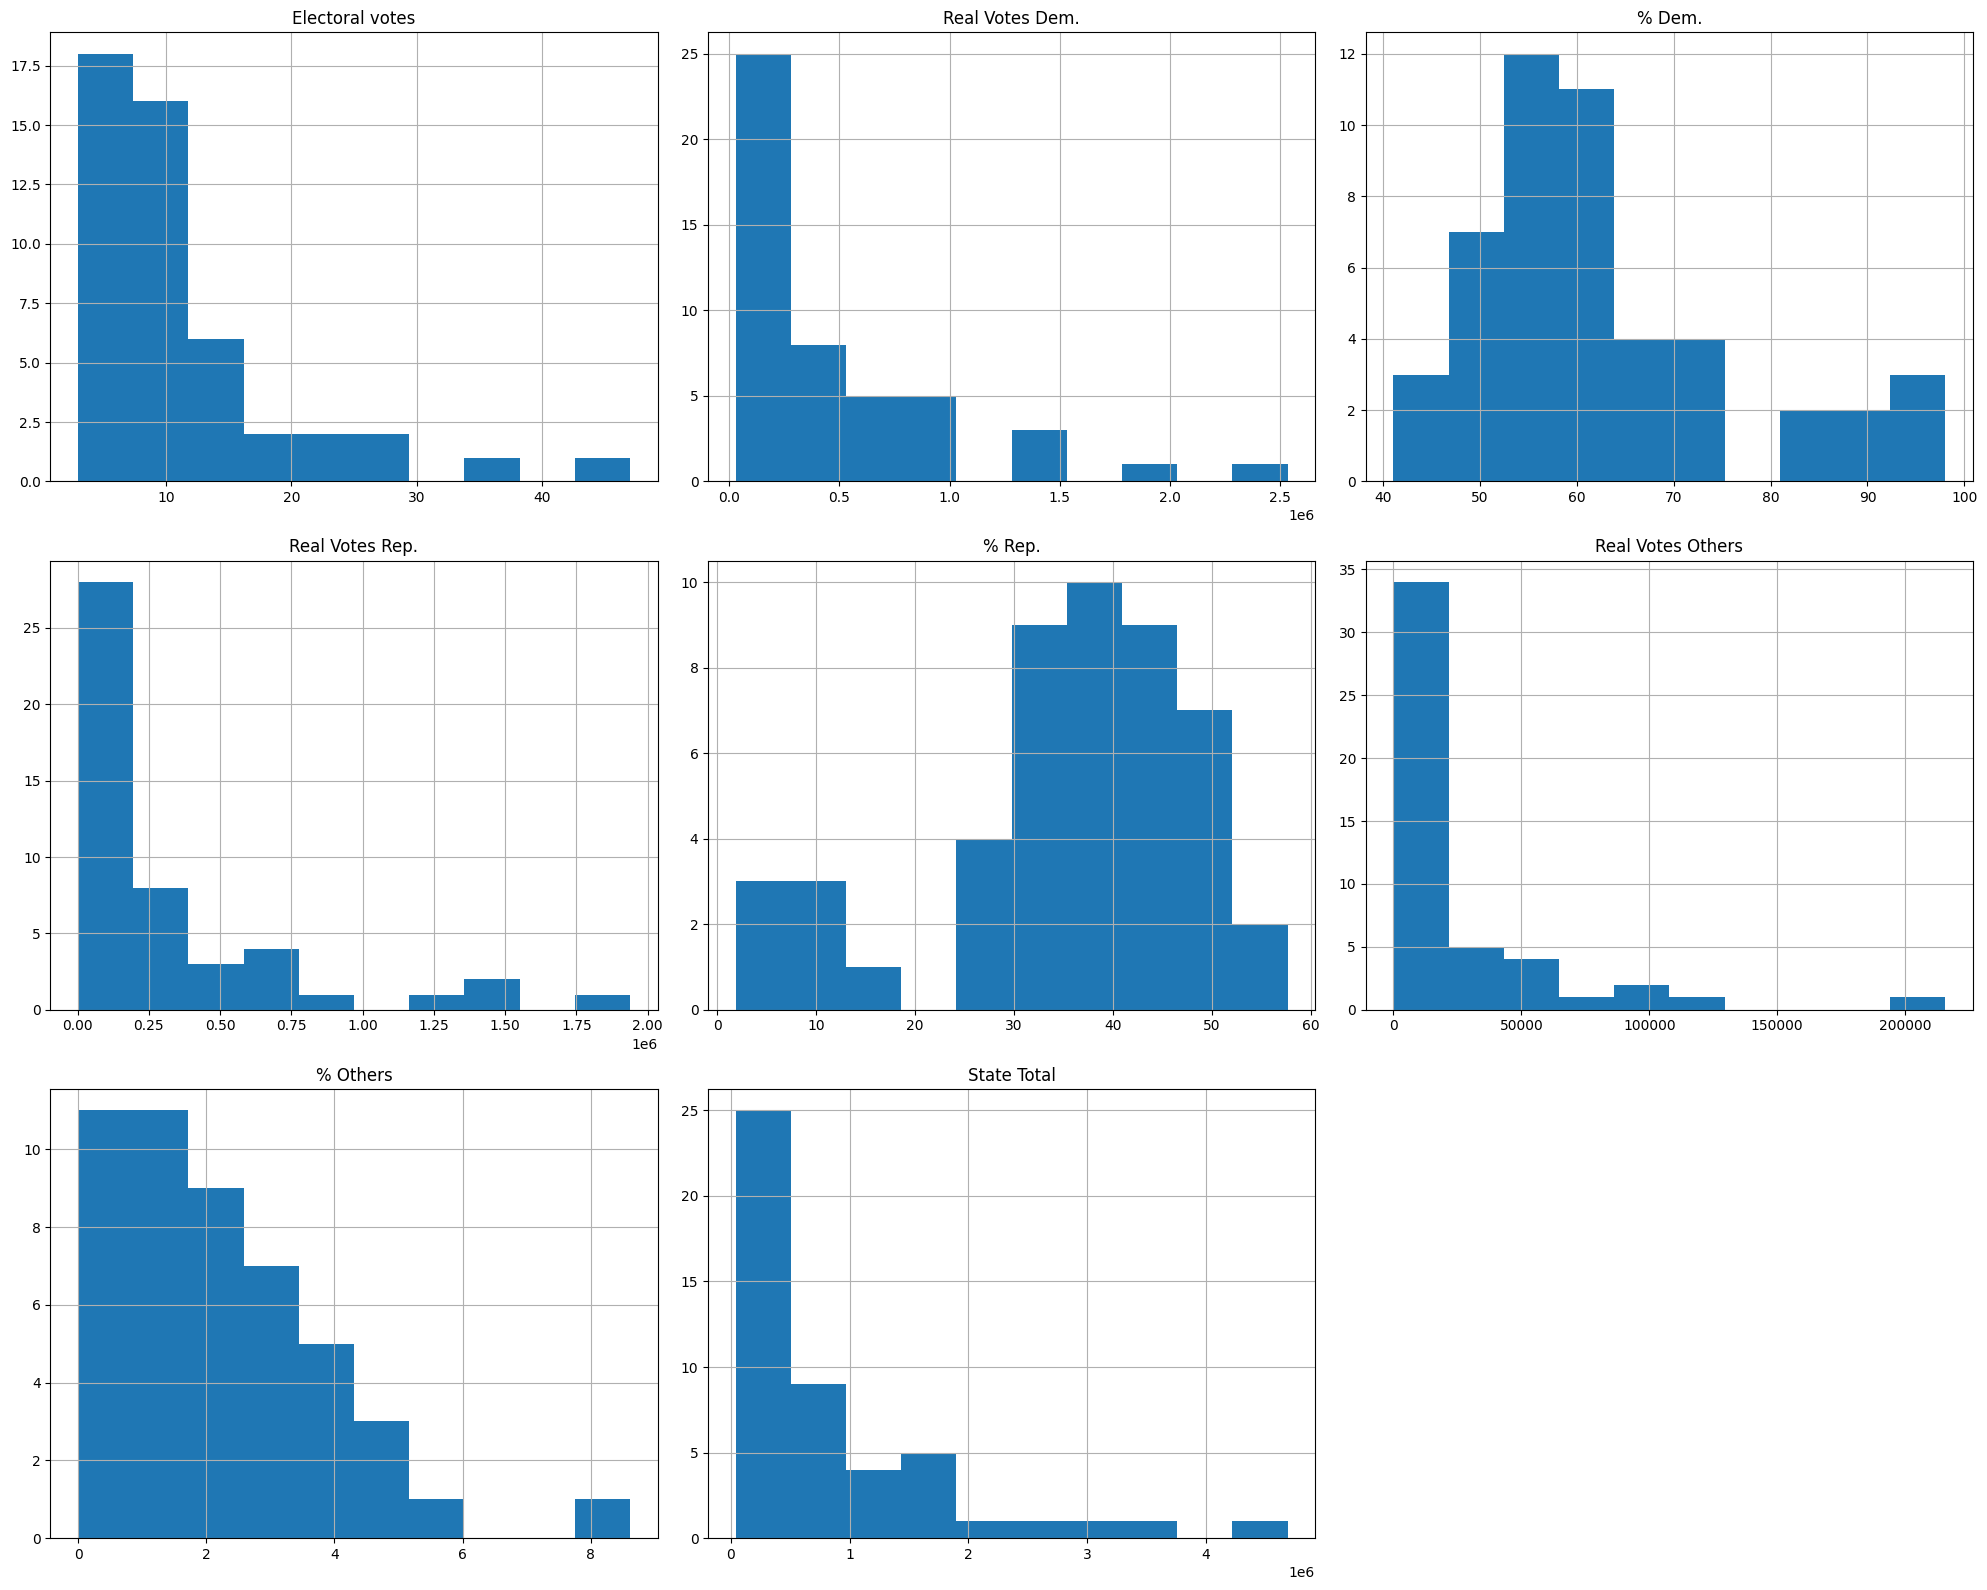

In [55]:
df_1932.hist(figsize=(20, 16))
plt.tight_layout()
plt.show()

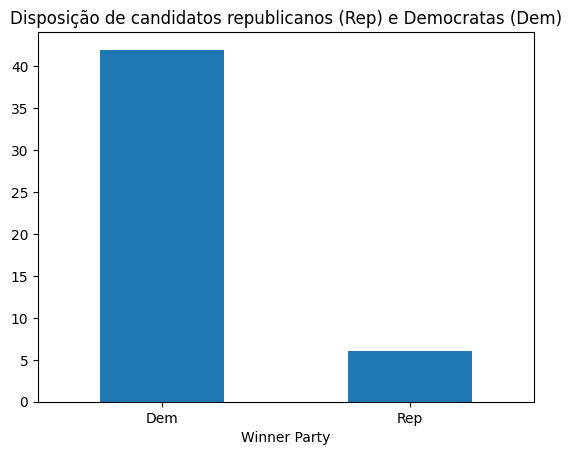

In [56]:
# Plota um gráfico de barras da distribuição do alvo(target)

df_1932["Winner Party"].value_counts().plot(kind="bar")

plt.xticks(rotation=0)
plt.title("Disposição de candidatos republicanos (Rep) e Democratas (Dem)")

plt.show()

- DataFrame 1936

In [57]:
df_1936.shape

(51, 56)

Esse código mostra quantas linhas e colunas o DataFrame de 1936 possui antes de começar o tratamento dos dados.

In [58]:
df_1936.isna().sum()

,0
Unnamed: 0,0
Unnamed: 1,0
Landon (R),0
How did they vote in 1932?,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0
Unnamed: 7,0
Unnamed: 8,0
Unnamed: 9,51


Esse código verifica, coluna por coluna, quantos valores nulos existem no DataFrame de 1936.

---



In [59]:
df_1936.duplicated().sum()

np.int64(0)

Esse código verifica se existem linhas inteiras duplicadas dentro do DataFrame de 1936.

In [60]:
df_1936.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 56 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    51 non-null     object 
 1   Unnamed: 1                    51 non-null     object 
 2   Landon  (R)                   51 non-null     object 
 3   How did they vote in 1932?    51 non-null     object 
 4   Unnamed: 4                    51 non-null     object 
 5   Unnamed: 5                    51 non-null     object 
 6   Unnamed: 6                    51 non-null     object 
 7   Unnamed: 7                    51 non-null     object 
 8   Unnamed: 8                    51 non-null     object 
 9   Unnamed: 9                    0 non-null      float64
 10  Roosevelt  (D)                51 non-null     object 
 11  How did they vote in 1932?.1  51 non-null     object 
 12  Unnamed: 12                   51 non-null     object 
 13  Unnamed

Esse código mostra um resumo geral da tabela de 1936, com o tipo de cada coluna, quantidade de valores não nulos e uso de memória.

In [61]:
df_1936.describe()

,Unnamed: 9,Unnamed: 17,Unnamed: 25,Unnamed: 33,Electoral votes,Roosevelt,%,Landon,%.1,Margin,%.5,Total votes
count,0.0,0.0,0.0,0.0,49.000000,4.900000e+01,49.000000,4.900000e+01,49.000000,4.900000e+01,49.000000,4.900000e+01
mean,NaN,NaN,NaN,NaN,21.673469,1.132766e+06,64.652653,6.809107e+05,32.978980,4.518688e+05,31.673673,1.863179e+06
std,NaN,NaN,NaN,NaN,74.808474,3.940307e+06,12.574029,2.378896e+06,11.829567,1.567596e+06,24.273271,6.490007e+06
min,NaN,NaN,NaN,NaN,3.000000,3.192500e+04,41.520000,1.646000e+03,1.430000,-4.249000e+04,-13.970000,4.384800e+04
25%,NaN,NaN,NaN,NaN,4.000000,1.573180e+05,56.880000,6.455500e+04,27.590000,8.569100e+04,16.400000,2.305120e+05
50%,NaN,NaN,NaN,NaN,9.000000,3.280830e+05,60.800000,1.688230e+05,36.540000,1.581770e+05,25.310000,4.886840e+05
75%,NaN,NaN,NaN,NaN,13.000000,7.344850e+05,69.340000,3.977270e+05,40.180000,3.170610e+05,40.840000,1.142733e+06
max,NaN,NaN,NaN,NaN,531.000000,2.775265e+07,98.570000,1.668186e+07,56.390000,1.107079e+07,97.150000,4.564770e+07


Esse código gera um resumo estatístico das colunas numéricas do DataFrame de 1936, mostrando média, desvio padrão, valores mínimo, máximo e os quartis.

In [62]:
df_pesquisa = df_1936.iloc[:, :34]
df_eleicao  = df_1936.iloc[:, 34:]

novos_nomes = df_pesquisa.iloc[0].to_dict()
df_pesquisa = df_pesquisa.rename(columns=novos_nomes)
df_pesquisa = df_pesquisa.drop(index=0).reset_index(drop=True)

# remove colunas separadoras vazias (sem nome)
df_pesquisa = df_pesquisa.loc[:, df_pesquisa.columns.notna()]

df_pesquisa.head()

,State,Electoral Vote,Landon,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,Roosevelt (D),Rep.,Dem.,Soc.,Others,Did Note Vote,Vote Not Indicated,Lemke,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,Thomas,Browder,Colvin,Aiken,Others,Totals,Total
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,371,8530,50,1,736,394,68,5,49,4,0,4,6,33,3,27,0,0,63,13273
1,Arizona,3,2337,1431,647,18,0,129,112,1975,248,1555,33,0,70,69,104,22,52,8,0,10,12,22,24,14,0,0,60,4476
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,228,6655,16,8,373,328,138,14,98,4,3,9,10,37,5,21,2,5,70,10540
3,California,22,89516,65360,16200,315,53,3519,4069,77245,15165,53520,1816,63,3578,3103,4977,1620,2560,117,25,163,492,728,967,398,44,60,2197,173935
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,1747,7256,284,13,439,286,579,136,333,29,2,26,53,122,49,41,10,11,233,26786


Esse bloco divide o DataFrame de 1936 em duas partes: pesquisa 34 primeiras colunas e eleição o restante. Como os nomes reais das colunas de pesquisa estão na primeira linha da tabela, o código pega essa linha, transforma em dicionário e renomeia as colunas com base nela. Depois apaga essa linha que já cumpriu sua função, reorganiza os índices e remove colunas vazias que serviam só de separador visual.

In [63]:
df_eleicao = df_eleicao.drop(columns=['State', 'Unnamed: 55'])
df_eleicao = df_eleicao.rename(columns={'State - 1936': 'State'})

df_eleicao.head()

,State,Electoral votes,Roosevelt,%,Electoral votes.1,Landon,%.1,Electoral votes.2,Lemke (Union).1,%.2,Electoral votes.3,Thomas (Soc.),%.3,Electoral votes.4,Other,%.4,Electoral votes.5,Margin,%.5,Total votes
0,Alabama,11.0,238136.0,86.38,11,35358.0,12.82,-,551,0.2,-,242,0.09,-,1397,0.51,-,202838.0,73.56,275244.0
1,Arizona,3.0,86722.0,69.85,3,33433.0,26.93,-,3307,2.66,-,317,0.26,-,384,0.31,-,53289.0,42.92,124163.0
2,Arkansas,9.0,146765.0,81.80,9,32039.0,17.86,-,4,0,-,446,0.25,-,169,0.09,-,114726.0,63.94,179423.0
3,California,22.0,1766836.0,66.95,22,836431.0,31.70,-,-,-,-,11331,0.43,-,24284,0.92,-,930405.0,35.26,2638882.0
4,Colorado,6.0,295021.0,60.37,6,181267.0,37.09,-,9962,2.04,-,1593,0.33,-,841,0.17,-,113754.0,23.28,488684.0


Esse bloco repete exatamente o mesmo processo do código anterior, separando novamente pesquisa e eleição e reorganizando os nomes das colunas.

In [64]:
df_pesquisa.loc[df_pesquisa.index[49], 'State'] = 'TOTALS:'
df_eleicao.loc[df_eleicao.index[49], 'State'] = 'TOTALS:'

df_1936 = pd.merge(df_pesquisa, df_eleicao, on='State')

df_1936

,State,Electoral Vote,Landon _x,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,Roosevelt (D),Rep.,Dem.,Soc.,Others,Did Note Vote,Vote Not Indicated,Lemke,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,Thomas,Browder,Colvin,Aiken,Others,Totals,Total,Electoral votes,Roosevelt,%,Electoral votes.1,Landon _y,%.1,Electoral votes.2,Lemke (Union).1,%.2,Electoral votes.3,Thomas (Soc.),%.3,Electoral votes.4,Other,%.4,Electoral votes.5,Margin,%.5,Total votes
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,371,8530,50,1,736,394,68,5,49,4,0,4,6,33,3,27,0,0,63,13273,11.0,238136.0,86.38,11,35358.0,12.82,-,551,0.2,-,242,0.09,-,1397,0.51,-,202838.0,73.56,275244.0
1,Arizona,3,2337,1431,647,18,0,129,112,1975,248,1555,33,0,70,69,104,22,52,8,0,10,12,22,24,14,0,0,60,4476,3.0,86722.0,69.85,3,33433.0,26.93,-,3307,2.66,-,317,0.26,-,384,0.31,-,53289.0,42.92,124163.0
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,228,6655,16,8,373,328,138,14,98,4,3,9,10,37,5,21,2,5,70,10540,9.0,146765.0,81.80,9,32039.0,17.86,-,4,0,-,446,0.25,-,169,0.09,-,114726.0,63.94,179423.0
3,California,22,89516,65360,16200,315,53,3519,4069,77245,15165,53520,1816,63,3578,3103,4977,1620,2560,117,25,163,492,728,967,398,44,60,2197,173935,22.0,1766836.0,66.95,22,836431.0,31.70,-,-,-,-,11331,0.43,-,24284,0.92,-,930405.0,35.26,2638882.0
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,1747,7256,284,13,439,286,579,136,333,29,2,26,53,122,49,41,10,11,233,26786,6.0,295021.0,60.37,6,181267.0,37.09,-,9962,2.04,-,1593,0.33,-,841,0.17,-,113754.0,23.28,488684.0
5,Connecticut,8,28809,22939,3376,111,7,1230,1146,13413,2584,9113,408,6,788,514,1489,245,1006,53,3,70,112,258,101,39,31,11,440,44151,8.0,382129.0,55.32,8,278685.0,40.35,-,21805,3.16,-,5683,0.82,-,2421,0.35,-,103444.0,14.98,690723.0
6,Delaware,3,2918,2343,328,9,0,134,104,2048,503,1345,34,0,96,70,35,6,19,3,0,2,5,16,2,8,0,1,27,5028,3.0,69702.0,54.62,3,57236.0,44.85,-,442,0.35,-,172,0.13,-,51,0.04,-,12466.0,9.77,127603.0
7,Florida,7,6087,3121,2051,13,5,594,303,8620,635,6924,41,0,614,406,195,37,116,6,2,12,22,58,22,31,6,2,119,15021,7.0,249117.0,76.10,7,78248.0,23.90,-,-,-,-,-,-,-,-,-,-,170869.0,52.20,327365.0
8,Georgia,12,3948,1239,1817,5,11,708,168,12915,379,10377,42,9,1569,539,35,3,23,1,0,6,2,45,12,27,0,17,101,16999,12.0,255364.0,87.10,12,36942.0,12.60,-,141,0.05,-,68,0.02,-,660,0.23,-,218422.0,74.50,293175.0
9,Idaho,4,3653,2672,698,9,8,103,163,2611,398,1989,30,8,89,97,224,69,109,8,11,9,18,34,3,17,1,3,58,6546,4.0,125683.0,62.96,4,66256.0,33.19,-,7678,3.85,-,-,-,-,-,-,-,59427.0,29.77,199617.0


Esse código substitui o valor da linha de totais em cada DataFrame pesquisa e eleição por "TOTALS:", garantindo que as duas tabelas tenham essa referência igual. Depois junta os dois DataFrames em um só, usando a coluna "State" como referência.

In [65]:
df_1936.isna().sum()

,0
State,0
Electoral Vote,0
Landon _x,0
Rep.,0
Dem.,0
Soc.,0
Others,0
Did Not Vote,0
Vote Not Indicated,0
Roosevelt (D),0


Esse código verifica novamente se sobraram valores nulos no DataFrame de 1936 depois da junção, para conferir se está tudo certo.

In [66]:
df_1936['Electoral votes.2'] = df_1936['Electoral votes.2'].replace('-', 0)
df_1936['Electoral votes.3'] = df_1936['Electoral votes.3'].replace('-', 0)
df_1936['Electoral votes.4'] = df_1936['Electoral votes.4'].replace('-', 0)
df_1936['Electoral votes.5'] = df_1936['Electoral votes.5'].replace('-', 0)

df_1936 = df_1936.replace('-', 0)

/tmp/ipykernel_4023/3681450487.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1936['Electoral votes.2'] = df_1936['Electoral votes.2'].replace('-', 0)
/tmp/ipykernel_4023/3681450487.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_1936['Electoral votes.3'] = df_1936['Electoral votes.3'].replace('-', 0)
/tmp/ipykernel_4023/3681450487.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

Esse código troca o traço "-" dado ausente por 0 em quatro colunas específicas de votos eleitorais, e depois faz essa mesma troca em toda a tabela de uma vez, garantindo que nenhum traço tenha sobrado em nenhuma coluna.

In [67]:
df_1936

,State,Electoral Vote,Landon _x,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,Roosevelt (D),Rep.,Dem.,Soc.,Others,Did Note Vote,Vote Not Indicated,Lemke,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,Thomas,Browder,Colvin,Aiken,Others,Totals,Total,Electoral votes,Roosevelt,%,Electoral votes.1,Landon _y,%.1,Electoral votes.2,Lemke (Union).1,%.2,Electoral votes.3,Thomas (Soc.),%.3,Electoral votes.4,Other,%.4,Electoral votes.5,Margin,%.5,Total votes
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,371,8530,50,1,736,394,68,5,49,4,0,4,6,33,3,27,0,0,63,13273,11.0,238136.0,86.38,11,35358.0,12.82,0,551,0.20,0,242,0.09,0,1397,0.51,0,202838.0,73.56,275244.0
1,Arizona,3,2337,1431,647,18,0,129,112,1975,248,1555,33,0,70,69,104,22,52,8,0,10,12,22,24,14,0,0,60,4476,3.0,86722.0,69.85,3,33433.0,26.93,0,3307,2.66,0,317,0.26,0,384,0.31,0,53289.0,42.92,124163.0
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,228,6655,16,8,373,328,138,14,98,4,3,9,10,37,5,21,2,5,70,10540,9.0,146765.0,81.80,9,32039.0,17.86,0,4,0.00,0,446,0.25,0,169,0.09,0,114726.0,63.94,179423.0
3,California,22,89516,65360,16200,315,53,3519,4069,77245,15165,53520,1816,63,3578,3103,4977,1620,2560,117,25,163,492,728,967,398,44,60,2197,173935,22.0,1766836.0,66.95,22,836431.0,31.70,0,0,0.00,0,11331,0.43,0,24284,0.92,0,930405.0,35.26,2638882.0
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,1747,7256,284,13,439,286,579,136,333,29,2,26,53,122,49,41,10,11,233,26786,6.0,295021.0,60.37,6,181267.0,37.09,0,9962,2.04,0,1593,0.33,0,841,0.17,0,113754.0,23.28,488684.0
5,Connecticut,8,28809,22939,3376,111,7,1230,1146,13413,2584,9113,408,6,788,514,1489,245,1006,53,3,70,112,258,101,39,31,11,440,44151,8.0,382129.0,55.32,8,278685.0,40.35,0,21805,3.16,0,5683,0.82,0,2421,0.35,0,103444.0,14.98,690723.0
6,Delaware,3,2918,2343,328,9,0,134,104,2048,503,1345,34,0,96,70,35,6,19,3,0,2,5,16,2,8,0,1,27,5028,3.0,69702.0,54.62,3,57236.0,44.85,0,442,0.35,0,172,0.13,0,51,0.04,0,12466.0,9.77,127603.0
7,Florida,7,6087,3121,2051,13,5,594,303,8620,635,6924,41,0,614,406,195,37,116,6,2,12,22,58,22,31,6,2,119,15021,7.0,249117.0,76.10,7,78248.0,23.90,0,0,0.00,0,0,0.00,0,0,0.00,0,170869.0,52.20,327365.0
8,Georgia,12,3948,1239,1817,5,11,708,168,12915,379,10377,42,9,1569,539,35,3,23,1,0,6,2,45,12,27,0,17,101,16999,12.0,255364.0,87.10,12,36942.0,12.60,0,141,0.05,0,68,0.02,0,660,0.23,0,218422.0,74.50,293175.0
9,Idaho,4,3653,2672,698,9,8,103,163,2611,398,1989,30,8,89,97,224,69,109,8,11,9,18,34,3,17,1,3,58,6546,4.0,125683.0,62.96,4,66256.0,33.19,0,7678,3.85,0,0,0.00,0,0,0.00,0,59427.0,29.77,199617.0


Esse código apenas mostra a tabela de 1936 completa na tela, para conferir como ela ficou depois do tratamento dos valores ausentes.

In [68]:
lista_partidos = []

for i in range(0, 49):
    republicanos = pd.to_numeric(df_1936.loc[df_1936.index[i], 'Landon   _y'], errors='coerce')
    democratas   = pd.to_numeric(df_1936.loc[df_1936.index[i], 'Roosevelt  '], errors='coerce')
    uniao        = pd.to_numeric(df_1936.loc[df_1936.index[i], 'Lemke (Union).1'], errors='coerce')
    socialistas  = pd.to_numeric(df_1936.loc[df_1936.index[i], 'Thomas (Soc.)'], errors='coerce')
    outros       = pd.to_numeric(df_1936.loc[df_1936.index[i], 'Other'], errors='coerce')

    partidos = {
        'Rep': republicanos,
        'Dem': democratas,
        'Union': uniao,
        'Soc': socialistas,
        'Other': outros
    }


    partido_vencedor = max(partidos, key=lambda k: partidos[k] if pd.notna(partidos[k]) else -1)

    lista_partidos.append(partido_vencedor)

df_1936['Winner Party'] = lista_partidos

df_1936

,State,Electoral Vote,Landon _x,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,Roosevelt (D),Rep.,Dem.,Soc.,Others,Did Note Vote,Vote Not Indicated,Lemke,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,Thomas,Browder,Colvin,Aiken,Others,Totals,Total,Electoral votes,Roosevelt,%,Electoral votes.1,Landon _y,%.1,Electoral votes.2,Lemke (Union).1,%.2,Electoral votes.3,Thomas (Soc.),%.3,Electoral votes.4,Other,%.4,Electoral votes.5,Margin,%.5,Total votes,Winner Party
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,371,8530,50,1,736,394,68,5,49,4,0,4,6,33,3,27,0,0,63,13273,11.0,238136.0,86.38,11,35358.0,12.82,0,551,0.20,0,242,0.09,0,1397,0.51,0,202838.0,73.56,275244.0,Dem
1,Arizona,3,2337,1431,647,18,0,129,112,1975,248,1555,33,0,70,69,104,22,52,8,0,10,12,22,24,14,0,0,60,4476,3.0,86722.0,69.85,3,33433.0,26.93,0,3307,2.66,0,317,0.26,0,384,0.31,0,53289.0,42.92,124163.0,Dem
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,228,6655,16,8,373,328,138,14,98,4,3,9,10,37,5,21,2,5,70,10540,9.0,146765.0,81.80,9,32039.0,17.86,0,4,0.00,0,446,0.25,0,169,0.09,0,114726.0,63.94,179423.0,Dem
3,California,22,89516,65360,16200,315,53,3519,4069,77245,15165,53520,1816,63,3578,3103,4977,1620,2560,117,25,163,492,728,967,398,44,60,2197,173935,22.0,1766836.0,66.95,22,836431.0,31.70,0,0,0.00,0,11331,0.43,0,24284,0.92,0,930405.0,35.26,2638882.0,Dem
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,1747,7256,284,13,439,286,579,136,333,29,2,26,53,122,49,41,10,11,233,26786,6.0,295021.0,60.37,6,181267.0,37.09,0,9962,2.04,0,1593,0.33,0,841,0.17,0,113754.0,23.28,488684.0,Dem
5,Connecticut,8,28809,22939,3376,111,7,1230,1146,13413,2584,9113,408,6,788,514,1489,245,1006,53,3,70,112,258,101,39,31,11,440,44151,8.0,382129.0,55.32,8,278685.0,40.35,0,21805,3.16,0,5683,0.82,0,2421,0.35,0,103444.0,14.98,690723.0,Dem
6,Delaware,3,2918,2343,328,9,0,134,104,2048,503,1345,34,0,96,70,35,6,19,3,0,2,5,16,2,8,0,1,27,5028,3.0,69702.0,54.62,3,57236.0,44.85,0,442,0.35,0,172,0.13,0,51,0.04,0,12466.0,9.77,127603.0,Dem
7,Florida,7,6087,3121,2051,13,5,594,303,8620,635,6924,41,0,614,406,195,37,116,6,2,12,22,58,22,31,6,2,119,15021,7.0,249117.0,76.10,7,78248.0,23.90,0,0,0.00,0,0,0.00,0,0,0.00,0,170869.0,52.20,327365.0,Dem
8,Georgia,12,3948,1239,1817,5,11,708,168,12915,379,10377,42,9,1569,539,35,3,23,1,0,6,2,45,12,27,0,17,101,16999,12.0,255364.0,87.10,12,36942.0,12.60,0,141,0.05,0,68,0.02,0,660,0.23,0,218422.0,74.50,293175.0,Dem
9,Idaho,4,3653,2672,698,9,8,103,163,2611,398,1989,30,8,89,97,224,69,109,8,11,9,18,34,3,17,1,3,58,6546,4.0,125683.0,62.96,4,66256.0,33.19,0,7678,3.85,0,0,0.00,0,0,0.00,0,59427.0,29.77,199617.0,Dem


Esse bloco percorre cada linha do DataFrame, transforma os votos de cada partido (Republicano, Democrata, União, Socialista e Outros) em números, e descobre qual teve o maior valor em cada estado. Diferente dos anos anteriores, aqui o código usa um dicionário para guardar os votos de cada partido e a função max para achar diretamente o nome do vencedor, tratando valores nulos como se fossem os menores possíveis. O resultado é guardado em uma lista e vira a nova coluna "Winner Party".

In [69]:
cols = []
count = {}

for col in df_1936.columns:
  if col in count:
    count[col] += 1
    cols.append(f'{col}.{count[col]}')
  else:
    count[col] = 0
    cols.append(col)

df_1936.columns = cols

novos_nomes = {
    'Electoral Vote': 'ELECTORAL VOTE',
    'Landon   _x': 'Votes Rep.',
    'Roosevelt (D)': 'Votes Dem.',
    'Lemke': 'Votes Others',
    'Rep.': 'Hist. Rep.',
    'Dem.': 'Hist. Dem.',
    'Soc.': 'Hist. Others',
    'Did Not Vote': 'Hist. No Vote',
    'Landon   _y': 'Real Votes Rep.',
    '%.1': '% Rep.',
    'Roosevelt  ': 'Real Votes Dem.',
    '%': '% Dem.',
    'Lemke (Union).1': 'Real Votes Others',
    '%.2': '% Others',
    '%.5': '% Margin',
    'State total': 'State Total'
}


df_1936.rename(columns=novos_nomes, inplace=True)

Esse bloco identifica colunas com nomes repetidos e adiciona um sufixo numérico para diferenciá-las. Em seguida, renomeia as colunas para nomes mais organizados, separando dados de pesquisa, histórico e resultado real da eleição de 1936.

In [70]:
df_1936.head(2)

,State,ELECTORAL VOTE,Votes Rep.,Hist. Rep.,Hist. Dem.,Hist. Others,Others,Hist. No Vote,Vote Not Indicated,Votes Dem.,Rep..1,Dem..1,Soc..1,Others.1,Did Note Vote,Vote Not Indicated.1,Votes Others,Rep..2,Dem..2,Soc..2,Others.2,Did Not Vote.1,Vote Not Indicated.2,Thomas,Browder,Colvin,Aiken,Others.3,Totals,Total,Electoral votes,Real Votes Dem.,% Dem.,Electoral votes.1,Real Votes Rep.,% Rep.,Electoral votes.2,Real Votes Others,% Others,Electoral votes.3,Thomas (Soc.),%.3,Electoral votes.4,Other,%.4,Electoral votes.5,Margin,% Margin,Total votes,Winner Party
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,371,8530,50,1,736,394,68,5,49,4,0,4,6,33,3,27,0,0,63,13273,11.0,238136.0,86.38,11,35358.0,12.82,0,551,0.20,0,242,0.09,0,1397,0.51,0,202838.0,73.56,275244.0,Dem
1,Arizona,3,2337,1431,647,18,0,129,112,1975,248,1555,33,0,70,69,104,22,52,8,0,10,12,22,24,14,0,0,60,4476,3.0,86722.0,69.85,3,33433.0,26.93,0,3307,2.66,0,317,0.26,0,384,0.31,0,53289.0,42.92,124163.0,Dem


Esse código mostra as duas primeiras linhas do DataFrame de 1936, para conferir como ficaram os nomes das colunas depois da renomeação.

In [71]:
df_1936['Votes Others'] = df_1936['Votes Others'] + df_1936['Thomas'] + df_1936['Browder'] + df_1936['Colvin'] + df_1936['Aiken'] + df_1936['Others.3']
df_1936['Hist. Others'] = df_1936['Hist. Others'] + df_1936['Others'] + df_1936['Soc..1'] + df_1936['Others.1'] + df_1936['Soc..1'] + df_1936['Others.2']
df_1936['Hist. Rep.'] = df_1936['Hist. Rep.'] + df_1936['Rep..1'] + df_1936['Rep..2']
df_1936['Hist. Dem.'] = df_1936['Hist. Dem.'] + df_1936['Dem..1'] + df_1936['Dem..2']
df_1936['Hist. No Vote'] = df_1936['Hist. No Vote'] + df_1936['Did Note Vote'] + df_1936['Did Not Vote.1']
df_1936['Real Votes Others'] = df_1936['Real Votes Others'] + df_1936['Thomas (Soc.)'] + df_1936['Other']
df_1936['% Others'] = df_1936['% Others'] + df_1936['%.3'] + df_1936['%.4']

df_1936 = df_1936.drop(columns=['Thomas', 'Browder', 'Colvin', 'Aiken', 'Others.3', 'Others', 'Soc..1', 'Others.1', 'Soc..2', 'Others.2', 'Rep..1', 'Rep..2', 'Dem..1', 'Dem..2', 'Thomas (Soc.)', 'Other', '%.3', '%.4', 'Electoral votes.1', 'Electoral votes.2', 'Electoral votes.3', 'Electoral votes.4', 'Vote Not Indicated', 'Vote Not Indicated.1', 'Vote Not Indicated.2', 'Totals', 'Electoral votes.5', 'Did Note Vote', 'Did Not Vote.1'])


df_1936

,State,ELECTORAL VOTE,Votes Rep.,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Votes Dem.,Votes Others,Total,Electoral votes,Real Votes Dem.,% Dem.,Real Votes Rep.,% Rep.,Real Votes Others,% Others,Margin,% Margin,Total votes,Winner Party
0,Alabama,11,3060,1594,9877,107,1152,10082,131,13273,11.0,238136.0,86.38,35358.0,12.82,2190,0.80,202838.0,73.56,275244.0,Dem
1,Arizona,3,2337,1701,2254,84,209,1975,164,4476,3.0,86722.0,69.85,33433.0,26.93,4008,3.23,53289.0,42.92,124163.0,Dem
2,Arkansas,9,2724,1580,7706,59,656,7608,208,10540,9.0,146765.0,81.80,32039.0,17.86,619,0.34,114726.0,63.94,179423.0,Dem
3,California,22,89516,82145,72280,4088,7260,77245,7174,173935,22.0,1766836.0,66.95,836431.0,31.70,35615,1.35,930405.0,35.26,2638882.0,Dem
4,Colorado,6,15949,13755,10303,726,1102,10025,812,26786,6.0,295021.0,60.37,181267.0,37.09,12396,2.54,113754.0,23.28,488684.0,Dem
5,Connecticut,8,28809,25768,13495,943,2088,13413,1929,44151,8.0,382129.0,55.32,278685.0,40.35,29909,4.33,103444.0,14.98,690723.0,Dem
6,Delaware,3,2918,2852,1692,77,232,2048,62,5028,3.0,69702.0,54.62,57236.0,44.85,665,0.52,12466.0,9.77,127603.0,Dem
7,Florida,7,6087,3793,9091,102,1220,8620,314,15021,7.0,249117.0,76.10,78248.0,23.90,0,0.00,170869.0,52.20,327365.0,Dem
8,Georgia,12,3948,1621,12217,109,2283,12915,136,16999,12.0,255364.0,87.10,36942.0,12.60,869,0.30,218422.0,74.50,293175.0,Dem
9,Idaho,4,3653,3139,2796,96,201,2611,282,6546,4.0,125683.0,62.96,66256.0,33.19,7678,3.85,59427.0,29.77,199617.0,Dem


Esse bloco soma os votos de candidatos e categorias menores em colunas únicas de "Others" tanto para votos, histórico, resultado real, quanto porcentagens, e também junta duplicidades das colunas de Republicano, Democrata e "Não Votou" que sobraram do processo de renomeação. Depois remove todas as colunas que já foram somadas e não são mais necessárias, deixando a tabela final mais limpa e organizada.

In [72]:
df_1936.shape

(49, 21)

Esse código mostra quantas linhas e colunas restaram no DataFrame de 1936 depois de toda a limpeza.

In [73]:
sorted(df_1936.columns)

['% Dem.',
 '% Margin',
 '% Others',
 '% Rep.',
 'ELECTORAL VOTE',
 'Electoral votes',
 'Hist. Dem.',
 'Hist. No Vote',
 'Hist. Others',
 'Hist. Rep.',
 'Margin',
 'Real Votes Dem.',
 'Real Votes Others',
 'Real Votes Rep.',
 'State',
 'Total',
 'Total votes',
 'Votes Dem.',
 'Votes Others',
 'Votes Rep.',
 'Winner Party']

Esse código mostra o nome de todas as colunas do DataFrame de 1936 organizadas em ordem alfabética, para ajudar a conferir se tudo ficou nomeado corretamente.

In [74]:
df_1936.columns.tolist()

['State',
 'ELECTORAL VOTE',
 'Votes Rep.',
 'Hist. Rep.',
 'Hist. Dem.',
 'Hist. Others',
 'Hist. No Vote',
 'Votes Dem.',
 'Votes Others',
 'Total',
 'Electoral votes',
 'Real Votes Dem.',
 '% Dem.',
 'Real Votes Rep.',
 '% Rep.',
 'Real Votes Others',
 '% Others',
 'Margin',
 '% Margin',
 'Total votes',
 'Winner Party']

Esse código mostra o nome de todas as colunas do DataFrame de 1936, mas na ordem em que elas aparecem na tabela (sem ordenar alfabeticamente).

In [75]:
df_1936.shape

(49, 21)

Esse código repete a checagem de linhas e colunas do DataFrame de 1936, para confirmar que nada mudou depois das últimas conferências.

In [76]:
df_1936.head(2)

,State,ELECTORAL VOTE,Votes Rep.,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Votes Dem.,Votes Others,Total,Electoral votes,Real Votes Dem.,% Dem.,Real Votes Rep.,% Rep.,Real Votes Others,% Others,Margin,% Margin,Total votes,Winner Party
0,Alabama,11,3060,1594,9877,107,1152,10082,131,13273,11.0,238136.0,86.38,35358.0,12.82,2190,0.80,202838.0,73.56,275244.0,Dem
1,Arizona,3,2337,1701,2254,84,209,1975,164,4476,3.0,86722.0,69.85,33433.0,26.93,4008,3.23,53289.0,42.92,124163.0,Dem


Esse código mostra as duas primeiras linhas do DataFrame de 1936 já com a estrutura final, para uma última conferida visual.

# Exploração visual

In [77]:
df_1924.columns.tolist()

['State',
 'ELECTORAL VOTE',
 'Votes Rep.',
 'Votes Dem.',
 'Votes Others',
 'Hist. Rep.',
 'Hist. Dem.',
 'Hist. Others',
 'Hist. No Vote',
 'Total',
 'Electoral votes',
 'Real Votes Rep.',
 '% Rep.',
 'Real Votes Dem.',
 '% Dem.',
 'Real Votes Others',
 '% Others',
 'Margin',
 '% Margin',
 'State Total',
 'Winner Party']

In [78]:
df_1928.columns.tolist()

['State',
 'ELECTORAL VOTE',
 'Votes Rep.',
 'Hist. Rep.',
 'Hist. Dem.',
 'Hist. Others',
 'Hist. No Vote',
 'Votes Dem.',
 'Votes Others',
 'Total',
 'Electoral votes',
 'Real Votes Rep.',
 '% Rep.',
 'Real Votes Dem.',
 '% Dem.',
 'Real Votes Others',
 '% Others',
 'Margin',
 '% Margin',
 'State Total',
 'Winner Party']

In [79]:
df_1932.columns.tolist()

['State',
 'ELECTORAL VOTE',
 'Votes Rep.',
 'Hist. Rep.',
 'Hist. Dem.',
 'Hist. Others',
 'Hist. No Vote',
 'Votes Dem.',
 'Votes Others',
 'Total',
 'Electoral votes',
 'Real Votes Dem.',
 '% Dem.',
 'Real Votes Rep.',
 '% Rep.',
 'Real Votes Others',
 '% Others',
 'Margin',
 '% Margin',
 'State Total',
 'Winner Party']

In [80]:
df_1936.columns.tolist()

['State',
 'ELECTORAL VOTE',
 'Votes Rep.',
 'Hist. Rep.',
 'Hist. Dem.',
 'Hist. Others',
 'Hist. No Vote',
 'Votes Dem.',
 'Votes Others',
 'Total',
 'Electoral votes',
 'Real Votes Dem.',
 '% Dem.',
 'Real Votes Rep.',
 '% Rep.',
 'Real Votes Others',
 '% Others',
 'Margin',
 '% Margin',
 'Total votes',
 'Winner Party']

Esses códigos mostram o nome de todas as colunas dos DataFrames de 1924, 1928, 1932 e 1936, na ordem em que aparecem, para conferir se os quatro anos ficaram com uma estrutura parecida antes de serem unidos.

In [81]:
df_pesquisa.columns.tolist()


['State',
 'Electoral Vote',
 'Landon   ',
 'Rep.',
 'Dem.',
 'Soc.',
 'Others',
 'Did Not Vote',
 'Vote Not Indicated',
 'Roosevelt (D)',
 'Rep.',
 'Dem.',
 'Soc.',
 'Others',
 'Did Note Vote',
 'Vote Not Indicated',
 'Lemke',
 'Rep.',
 'Dem.',
 'Soc.',
 'Others',
 'Did Not Vote',
 'Vote Not Indicated',
 'Thomas',
 'Browder',
 'Colvin',
 'Aiken',
 'Others',
 'Totals',
 'Total']

Esse código mostra as colunas que sobraram na variável df_pesquisa a última usada, referente a 1936, provavelmente para conferir algum detalhe específico dela.

In [82]:
df_1924.shape

(47, 21)

In [83]:
df_1928.shape

(48, 21)

In [84]:
df_1932.shape

(48, 21)

In [85]:
df_1936.shape

(49, 21)

Esses códigos mostram quantas linhas e colunas cada DataFrame 1924, 1928, 1932 e 1936 tem, para confirmar se todos ficaram com uma quantidade de colunas compatível antes de serem unidos em uma tabela só.

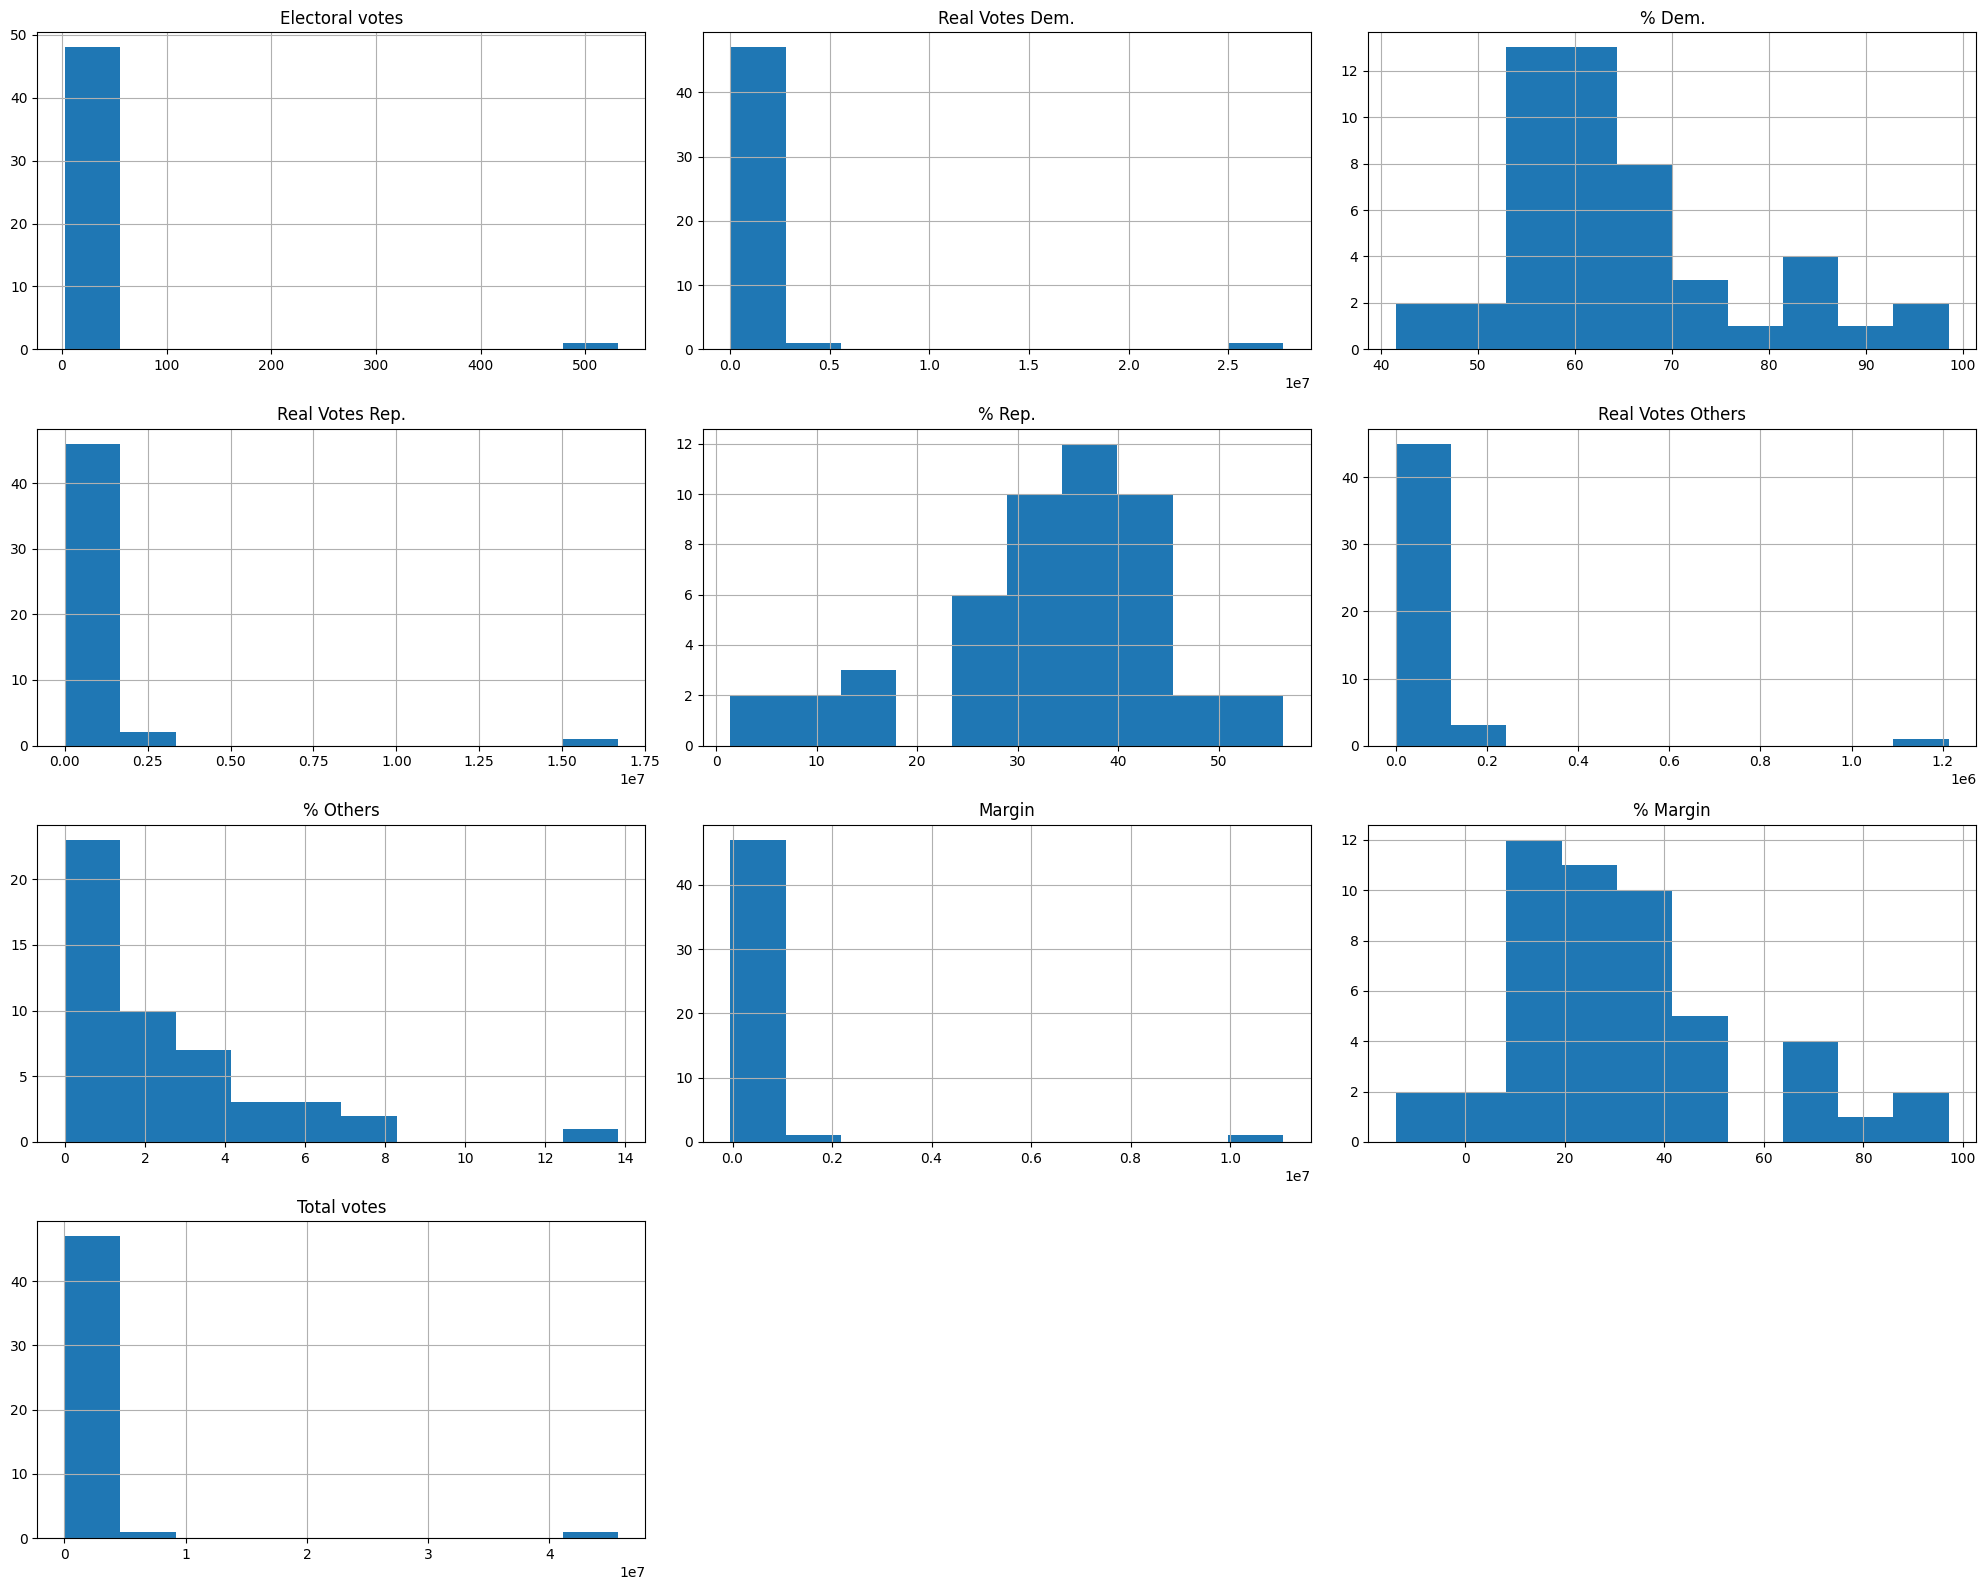

In [86]:
df_1936.hist(figsize=(20, 16))
plt.tight_layout()
plt.show()

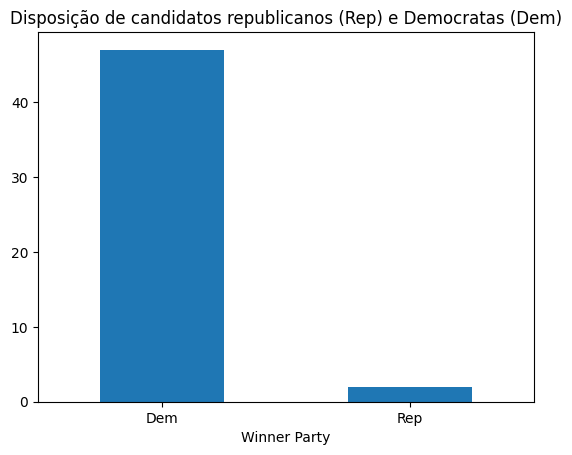

In [87]:
# Plota um gráfico de barras da distribuição do alvo(target)

df_1936["Winner Party"].value_counts().plot(kind="bar")

plt.xticks(rotation=0)
plt.title("Disposição de candidatos republicanos (Rep) e Democratas (Dem)")

plt.show()

## Divisão de dados

In [88]:
df_train = pd.concat([df_1924, df_1928, df_1932], ignore_index=True)

df_train

,State,ELECTORAL VOTE,Votes Rep.,Votes Dem.,Votes Others,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Total,Electoral votes,Real Votes Rep.,% Rep.,Real Votes Dem.,% Dem.,Real Votes Others,% Others,Margin,% Margin,State Total,Winner Party
0,Alabama,12.0,5752,12186,1869,3943,12081,48,3735,19807,12.0,45005.0,27.01,112966.0,67.81,8622.0,5.17,-67961.0,-40.79,166593.0,Dem
1,Arizona,3.0,4272,2005,2316,3978,2966,62,1587,8593,3.0,30516.0,41.26,26235.0,35.47,17210.0,23.27,4281.0,5.79,73961.0,Rep
2,Arkansas,9.0,5818,11210,2129,4534,11266,71,3286,19157,9.0,40564.0,29.28,84795.0,61.21,13173.0,9.51,-44231.0,-31.93,138532.0,Dem
3,California,13.0,76730,10280,67238,92052,25214,2801,34181,154248,13.0,733250.0,57.20,105514.0,8.23,443014.0,34.56,308601.0,24.07,1281900.0,Rep
4,Colorado,6.0,19225,4711,6528,17293,6577,253,6341,30464,6.0,195171.0,57.02,75238.0,21.98,71851.0,20.99,119933.0,35.04,342260.0,Rep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,Virginia,11,13440,34191,1609,17994,22248,25,7364,49240,11.0,89637.0,30.09,203979.0,68.46,4326.0,1.45,114342,38.38,297942.0,Dem
139,Washington,8,16717,30324,2776,28682,11534,50,6775,49817,8.0,208645.0,33.94,353260.0,57.46,52909.0,8.61,144615,23.52,614814.0,Dem
140,West Virginia,8,14365,23153,1177,18550,14358,27,4583,38695,8.0,330731.0,44.47,405124.0,54.47,7919.0,1.06,74393,10,743774.0,Dem
141,Wisconsin,12,21375,44054,5047,37038,19353,181,8857,70476,12.0,347741.0,31.19,707410.0,63.46,59657.0,5.35,359669,32.26,1114808.0,Dem


Esse código junta os DataFrames de 1924, 1928 e 1932 em um único DataFrame de treino, empilhando as linhas de cada ano uma embaixo da outra e reiniciando os índices.

In [89]:
pd.set_option('display.max_rows', None)

Esse código remove o limite de linhas mostradas pelo pandas, para poder ver o DataFrame de treino por inteiro, sem cortes.

In [90]:
df_train.isna().sum()

,0
State,0
ELECTORAL VOTE,0
Votes Rep.,0
Votes Dem.,0
Votes Others,0
Hist. Rep.,0
Hist. Dem.,0
Hist. Others,0
Hist. No Vote,0
Total,0


Esse código verifica se existem valores nulos no DataFrame de treino já unificado, para garantir que a junção dos três anos não deixou nada faltando.

In [91]:
df_test = df_1936.copy()

df_test = df_test.reindex(columns=df_train.columns)

df_test

,State,ELECTORAL VOTE,Votes Rep.,Votes Dem.,Votes Others,Hist. Rep.,Hist. Dem.,Hist. Others,Hist. No Vote,Total,Electoral votes,Real Votes Rep.,% Rep.,Real Votes Dem.,% Dem.,Real Votes Others,% Others,Margin,% Margin,State Total,Winner Party
0,Alabama,11,3060,10082,131,1594,9877,107,1152,13273,11.0,35358.0,12.82,238136.0,86.38,2190,0.80,202838.0,73.56,NaN,Dem
1,Arizona,3,2337,1975,164,1701,2254,84,209,4476,3.0,33433.0,26.93,86722.0,69.85,4008,3.23,53289.0,42.92,NaN,Dem
2,Arkansas,9,2724,7608,208,1580,7706,59,656,10540,9.0,32039.0,17.86,146765.0,81.80,619,0.34,114726.0,63.94,NaN,Dem
3,California,22,89516,77245,7174,82145,72280,4088,7260,173935,22.0,836431.0,31.70,1766836.0,66.95,35615,1.35,930405.0,35.26,NaN,Dem
4,Colorado,6,15949,10025,812,13755,10303,726,1102,26786,6.0,181267.0,37.09,295021.0,60.37,12396,2.54,113754.0,23.28,NaN,Dem
5,Connecticut,8,28809,13413,1929,25768,13495,943,2088,44151,8.0,278685.0,40.35,382129.0,55.32,29909,4.33,103444.0,14.98,NaN,Dem
6,Delaware,3,2918,2048,62,2852,1692,77,232,5028,3.0,57236.0,44.85,69702.0,54.62,665,0.52,12466.0,9.77,NaN,Dem
7,Florida,7,6087,8620,314,3793,9091,102,1220,15021,7.0,78248.0,23.90,249117.0,76.10,0,0.00,170869.0,52.20,NaN,Dem
8,Georgia,12,3948,12915,136,1621,12217,109,2283,16999,12.0,36942.0,12.60,255364.0,87.10,869,0.30,218422.0,74.50,NaN,Dem
9,Idaho,4,3653,2611,282,3139,2796,96,201,6546,4.0,66256.0,33.19,125683.0,62.96,7678,3.85,59427.0,29.77,NaN,Dem


Esse código cria uma cópia do DataFrame de 1936 para servir como dado de teste, e reorganiza suas colunas para ficarem na mesma ordem e com os mesmos nomes das colunas do DataFrame de treino.

In [92]:
df_test = df_test.drop(48)

In [93]:
# Define x_train com um DataFrame colocando os valores das colunas de df_train entre 0 e 1
x_train = pd.DataFrame({
    'RepShare':        df_train['Votes Rep.']   / df_train['Total'],
    'DemShare':        df_train['Votes Dem.']   / df_train['Total'],
    'OthersShare':     df_train['Votes Others'] / df_train['Total'],
    'HistRepShare':    df_train['Hist. Rep.']   / df_train['Total'],
    'HistDemShare':    df_train['Hist. Dem.']   / df_train['Total'],
    'HistOthersShare': df_train['Hist. Others'] / df_train['Total'],
    'SwingRep':        df_train['Votes Rep.']/df_train['Total'] - df_train['Hist. Rep.']/df_train['Total'],
    'SwingDem':        df_train['Votes Dem.']/df_train['Total'] - df_train['Hist. Dem.']/df_train['Total'],
})
y_train = df_train['Winner Party']

In [94]:
x_train.head()

,RepShare,DemShare,OthersShare,HistRepShare,HistDemShare,HistOthersShare,SwingRep,SwingDem
0,0.290402,0.615237,0.094361,0.199071,0.609936,0.002423,0.091331,0.005301
1,0.497149,0.233329,0.269522,0.462935,0.345165,0.007215,0.034214,-0.111835
2,0.303701,0.585165,0.111134,0.236676,0.588088,0.003706,0.067025,-0.002923
3,0.497446,0.066646,0.435908,0.596779,0.163464,0.018159,-0.099334,-0.096818
4,0.631073,0.154642,0.214286,0.567654,0.215894,0.008305,0.063419,-0.061253


In [95]:
# Define x_test com um DataFrame colocando os valores das colunas de df_test entre 0 e 1
x_test = pd.DataFrame({
    'RepShare':        df_test['Votes Rep.']   / df_test['Total'],
    'DemShare':        df_test['Votes Dem.']   / df_test['Total'],
    'OthersShare':     df_test['Votes Others'] / df_test['Total'],
    'HistRepShare':    df_test['Hist. Rep.']   / df_test['Total'],
    'HistDemShare':    df_test['Hist. Dem.']   / df_test['Total'],
    'HistOthersShare': df_test['Hist. Others'] / df_test['Total'],
    'SwingRep':        df_test['Votes Rep.']/df_test['Total'] - df_test['Hist. Rep.']/df_test['Total'],
    'SwingDem':        df_test['Votes Dem.']/df_test['Total'] - df_test['Hist. Dem.']/df_test['Total'],
})
y_test = df_test['Winner Party']

In [96]:
x_test.head()

,RepShare,DemShare,OthersShare,HistRepShare,HistDemShare,HistOthersShare,SwingRep,SwingDem
0,0.230543,0.759587,0.00987,0.120093,0.744142,0.008061,0.11045,0.015445
1,0.522118,0.441242,0.03664,0.380027,0.503575,0.018767,0.142091,-0.062332
2,0.258444,0.721822,0.019734,0.149905,0.73112,0.005598,0.108539,-0.009298
3,0.514652,0.444103,0.041245,0.472274,0.415558,0.023503,0.042378,0.028545
4,0.595423,0.374263,0.030314,0.513515,0.384641,0.027104,0.081908,-0.010379


In [97]:
print(f'Dados de Treinamento: {x_train.shape}\n')
print(f'Dados de Teste: {x_test.shape}\n')
print(f'Dados Target de treinamento: {y_train.value_counts()}\n')
print(f'Dados de Target de teste: {y_test.value_counts()}\n')

Dados de Treinamento: (143, 8)

Dados de Teste: (48, 8)

Dados Target de treinamento: Winner Party
Rep    80
Dem    63
Name: count, dtype: int64

Dados de Target de teste: Winner Party
Dem    46
Rep     2
Name: count, dtype: int64



Esse código imprime na tela o formato linhas e colunas dos conjuntos de treino e teste, além de mostrar quantos exemplos de cada classe Republicano e Democrata existem tanto no treino quanto no teste, para conferir se está tudo balanceado e pronto para o modelo.

In [98]:
#tentar adicionar mais uma coluna para ver o quanto um Estado mudou de voto
#clima nacional de cada eleição de treino 1924 1928 1932
swing_1924 = df_1924['Votes Dem.'].sum()/df_1924['Total'].sum() - df_1924['Hist. Dem.'].sum()/df_1924['Total'].sum()
swing_1928 = df_1928['Votes Dem.'].sum()/df_1928['Total'].sum() - df_1928['Hist. Dem.'].sum()/df_1928['Total'].sum()
swing_1932 = df_1932['Votes Dem.'].sum()/df_1932['Total'].sum() - df_1932['Hist. Dem.'].sum()/df_1932['Total'].sum()

Esse código calcula, para cada ano de treino 1924, 1928 e 1932, a diferença entre a proporção de votos democratas obtidos na eleição e a proporção histórica de votos democratas, gerando um número que representa o "clima nacional" a tendência geral do país em cada eleição.

In [99]:
anos = [1924]*len(df_1924) + [1928]*len(df_1928) + [1932]*len(df_1932)
x_train['NationalSwingDem'] = pd.Series(anos).map({1924: swing_1924, 1928: swing_1928, 1932: swing_1932}).values

# e o mesmo para 1936 usando só a previsão da própria pesquisa
x_test['NationalSwingDem'] = df_1936['Votes Dem.'].sum()/df_1936['Total'].sum() - df_1936['Hist. Dem.'].sum()/df_1936['Total'].sum()

Esse código cria uma lista indicando de qual ano é cada linha do DataFrame de treino, e usa isso para atribuir o valor de swing nacional calculado antes a cada linha, criando a coluna "NationalSwingDem" em x_train. Depois faz o mesmo para o DataFrame de teste 1936, calculando o swing nacional daquele ano e aplicando em todas as linhas.

## Treinamento

In [100]:
# treino com C=100
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=100.0, gamma='scale', random_state=42))
])
pipeline_svm.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=100.0, random_state=42))])

Esse código monta um pipeline que primeiro padroniza os dados deixando todos na mesma escala e depois treina um modelo SVM com kernel RBF, ajustando o parâmetro C para 100.0 e usando pesos balanceados entre as classes, para lidar melhor com eventuais diferenças na quantidade de exemplos de cada partido.

## Teste e Avaliação

In [101]:
y_pred = pipeline_svm.predict(x_test)

acc_score = accuracy_score(y_pred, y_test)

print(f'Acurácia: {acc_score:.4f}')

Acurácia: 0.7917


Esse código usa o modelo treinado para prever os vencedores dos estados no conjunto de teste 1936, e depois calcula a acurácia, ou seja, a porcentagem de acertos do modelo.

In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Dem       1.00      0.78      0.88        46
         Rep       0.17      1.00      0.29         2

    accuracy                           0.79        48
   macro avg       0.58      0.89      0.58        48
weighted avg       0.97      0.79      0.85        48



Esse código mostra um relatório detalhado com métricas de precisão, revocação e F1-score para cada classe Republicano e Democrata, dando uma visão mais completa do desempenho do modelo além da acurácia geral.

In [103]:
# teste para ver erros

erros = x_test.copy()
erros['Estado'] = df_test['State'].values
erros['Real'] = y_test.values
erros['Previsto'] = y_pred
erros[erros['Real'] != erros['Previsto']][['Estado', 'Real', 'Previsto', 'SwingDem', 'HistDemShare']]

,Estado,Real,Previsto,SwingDem,HistDemShare
5,Connecticut,Dem,Rep,-0.001857,0.305656
6,Delaware,Dem,Rep,0.070804,0.336516
11,Indiana,Dem,Rep,-0.035783,0.405584
13,Kansas,Dem,Rep,-0.014735,0.370868
18,Massachusetts,Dem,Rep,-0.044305,0.260989
25,Nevada,Dem,Rep,-0.027322,0.501739
26,New Hampshire,Dem,Rep,-0.044912,0.265602
27,New Jersey,Dem,Rep,-0.014123,0.321633
36,Rhode Island,Dem,Rep,-0.053651,0.289108
45,West Virginia,Dem,Rep,-0.028996,0.451755


Esse código monta uma tabela juntando o nome do estado, o resultado real e o resultado previsto pelo modelo, e filtra apenas as linhas onde o modelo errou, mostrando também algumas colunas extras Swing e histórico democrata para ajudar a entender onde e por que o modelo se confundiu.

In [104]:
print("Valores preditos:", y_pred)
print("Valores reais:", y_test)

Valores preditos: ['Dem' 'Dem' 'Dem' 'Dem' 'Dem' 'Rep' 'Rep' 'Dem' 'Dem' 'Dem' 'Dem' 'Rep'
 'Dem' 'Rep' 'Dem' 'Dem' 'Rep' 'Dem' 'Rep' 'Dem' 'Dem' 'Dem' 'Dem' 'Dem'
 'Dem' 'Rep' 'Rep' 'Rep' 'Dem' 'Dem' 'Dem' 'Dem' 'Dem' 'Dem' 'Dem' 'Dem'
 'Rep' 'Dem' 'Dem' 'Dem' 'Dem' 'Dem' 'Rep' 'Dem' 'Dem' 'Rep' 'Dem' 'Dem']
Valores reais: 0     Dem
1     Dem
2     Dem
3     Dem
4     Dem
5     Dem
6     Dem
7     Dem
8     Dem
9     Dem
10    Dem
11    Dem
12    Dem
13    Dem
14    Dem
15    Dem
16    Rep
17    Dem
18    Dem
19    Dem
20    Dem
21    Dem
22    Dem
23    Dem
24    Dem
25    Dem
26    Dem
27    Dem
28    Dem
29    Dem
30    Dem
31    Dem
32    Dem
33    Dem
34    Dem
35    Dem
36    Dem
37    Dem
38    Dem
39    Dem
40    Dem
41    Dem
42    Rep
43    Dem
44    Dem
45    Dem
46    Dem
47    Dem
Name: Winner Party, dtype: object


Esse código simplesmente imprime lado a lado os valores que o modelo previu e os valores reais, para uma conferência rápida e direta.

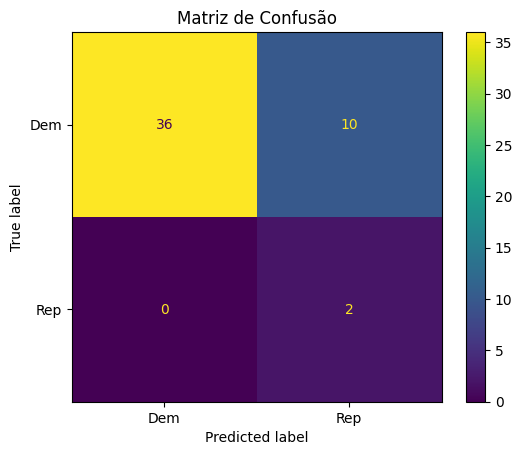

In [105]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = y_train.unique())

display.plot()
plt.title('Matriz de Confusão')
plt.show()

Esse código monta a matriz de confusão comparando os valores reais com os previstos, e desenha essa matriz em um gráfico colorido, onde o modelo acertou e onde ele confundiu Republicanos com Democratas.

## Comparativos

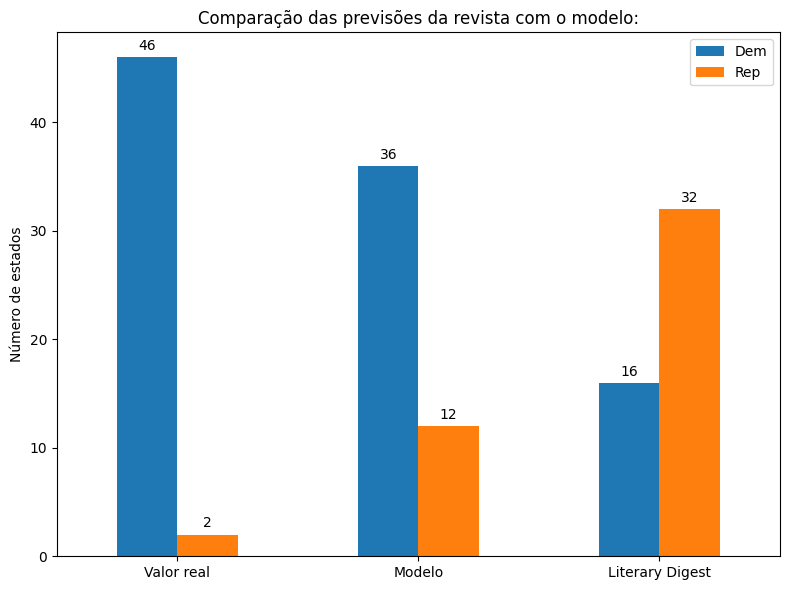

In [106]:
vencedor_previsao_revista = np.where(df_test['Votes Dem.'] > df_test['Votes Rep.'], 'Dem', 'Rep')

valor_real = pd.Series(y_test).value_counts()
previsao_modelo = pd.Series(y_pred).value_counts()
previsao_revista = pd.Series(vencedor_previsao_revista).value_counts()

df_comparativo = pd.DataFrame({
    'Valor real': valor_real,
    'Modelo': previsao_modelo,
    'Literary Digest': previsao_revista
})

ax = df_comparativo.T.plot(kind='bar', figsize=(8, 6))

for container in ax.containers:
  ax.bar_label(container, padding=3)

plt.title('Comparação das previsões da revista com o modelo:')
plt.ylabel('Número de estados')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

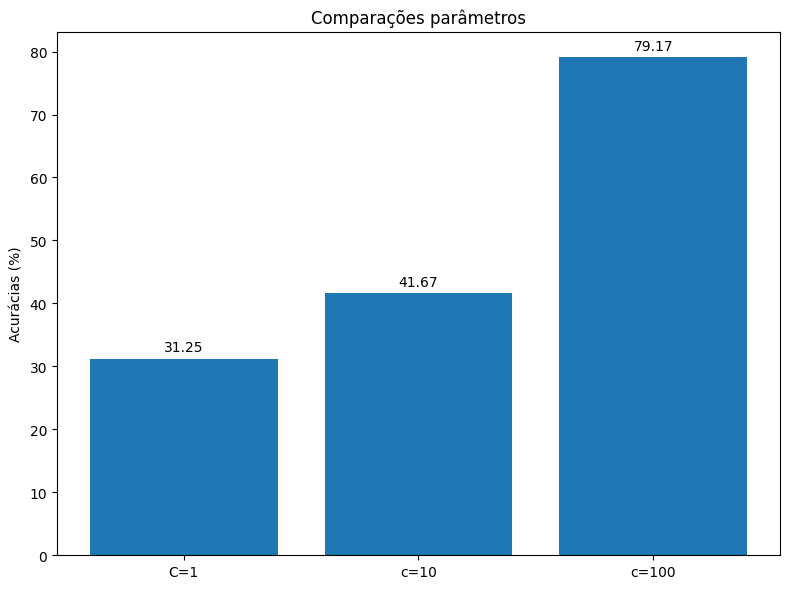

In [107]:
testes = ['C=1', 'c=10', 'c=100']
acuracias = [31.25,  41.67, 79.17]

plt.figure(figsize=(8, 6))
ax = plt.bar(testes, acuracias)

plt.bar_label(ax, padding=3)

plt.title('Comparações parâmetros')
plt.ylabel('Acurácias (%)')

plt.tight_layout()
plt.show()